# CMS Calorimeter Super-Resolution — Point Cloud Pipeline
**GSoC 2026 | ML4Sci / CMS | Rajveer Rathod**

---

## What This Notebook Does

CMS calorimeter data is fundamentally a **sparse point cloud** — millions of (η, φ, E) energy deposits.  
Standard grid-based SR models discard this physics-motivated structure. This notebook builds a
**resolution-invariant** super-resolution pipeline that:

1. **Explores** the raw HDF5 dataset structure and visualises jet images
2. **Builds a point cloud representation** from calorimeter images (aggregation + zero suppression)
3. **Simulates the LR detector readout** — multi-scale downsampling ladder (256→125→64) with buffer rounding
4. **Trains a resolution-invariant SR model** (Implicit Neural Representation + PointNet encoder)
   - Query any (η, φ) coordinate → predict energy at that location
   - No fixed input/output grid → works at 64×64, 125×125, 256×256, or 1M-point prediction
5. **Evaluates** with physics metrics: energy response, zero-suppression fidelity, PSNR vs bicubic

### Architecture Summary
```
LR Image (any res)
     │
     ▼
Point Cloud Extractor   ← (η, φ, E) active deposits only  
     │
     ▼
PointNet Encoder        ← permutation invariant, resolution invariant
     │  latent z (global scene representation)
     ▼
INR Decoder (SIREN/MLP) ← query ANY (η, φ) → predict E at that location
     │
     ▼
Rasterise to target res ← 64, 125, 256, or 1M points — your choice
```

---

In [ ]:
%pip install numpy h5py torch matplotlib
%pip install torch torchvision torchaudio

In [ ]:
# ── Cell 1: Install / imports ────────────────────────────────────────────────
# Kaggle already has torch, h5py, matplotlib — install extras if needed
import subprocess, sys

# def pip(pkg):
#     subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '-q'])

# Uncomment on Kaggle if missing:
# pip('einops')

import os, math, random
import numpy as np
import h5py
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.colors import LogNorm
import warnings
warnings.filterwarnings('ignore')

# ── Reproducibility ──────────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# ── Device selection (CUDA → Apple MPS → CPU) ────────────────────────────────
if torch.cuda.is_available():
    DEVICE = 'cuda'
elif torch.backends.mps.is_available():
    DEVICE = 'mps'
else:
    DEVICE = 'cpu'

# pin_memory only helps on CUDA; flag it so DataLoaders can adapt
PIN_MEMORY = (DEVICE == 'cuda')

print(f'Device: {DEVICE}')
print(f'PyTorch: {torch.__version__}')
if DEVICE == 'mps':
    print('Using Apple Silicon GPU (Metal Performance Shaders)')

# ── Figure saving (per-run dated folder) ──────────────────────────────────────
from datetime import datetime

FIGURES_ROOT = '/Users/rajveerrathod/Work/Google_Summer_of_code/GAN/figures'
# Each run saves into figures/<YYYY-MM-DD>/ . Set RUN_TAG before this cell to
# override (e.g. '2026-06-07_exp2' to keep multiple runs from the same day).
RUN_TAG = globals().get('RUN_TAG', datetime.now().strftime('%Y-%m-%d'))
FIGURES_DIR = os.path.join(FIGURES_ROOT, RUN_TAG)
os.makedirs(FIGURES_DIR, exist_ok=True)
print(f'Figures will be saved to: {FIGURES_DIR}')

def savefig(fig, name, dpi=150):
    """Save a matplotlib figure into figures/<date>/ as <name>.png."""
    path = os.path.join(FIGURES_DIR, f'{name}.png')
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f'  saved figure -> {path}')
    return path


---
## 1 · Dataset Exploration

In [2]:
# ── Cell 2: Locate dataset files ─────────────────────────────────────────────
DATASET_DIR = '/Users/rajveerrathod/Work/Google_Summer_of_code/GAN/dataset'

hdf5_files = []
for root, dirs, files in os.walk(DATASET_DIR):
    for f in files:
        if f.endswith('.hdf5') or f.endswith('.h5'):
            hdf5_files.append(os.path.join(root, f))

print('Found HDF5 files:')
for p in hdf5_files:
    size_mb = os.path.getsize(p) / 1e6
    print(f'  {p}  ({size_mb:.1f} MB)')

Found HDF5 files:
  /Users/rajveerrathod/Work/Google_Summer_of_code/GAN/dataset/dataset_2_2.hdf5  (1366.7 MB)
  /Users/rajveerrathod/Work/Google_Summer_of_code/GAN/dataset/dataset_2_1.hdf5  (1356.5 MB)


In [3]:
# ── Cell 3: Inspect HDF5 structure ───────────────────────────────────────────
def explore_hdf5(path, indent=0):
    """Recursively print HDF5 file tree with shapes & dtypes."""
    with h5py.File(path, 'r') as f:
        def _walk(name, obj):
            pad = '  ' * (name.count('/') + 1)
            if isinstance(obj, h5py.Dataset):
                print(f'{pad}📊 {name}  shape={obj.shape}  dtype={obj.dtype}  '
                      f'min={float(np.min(obj[:5])):.4f}  max={float(np.max(obj[:5])):.4f}')
            else:
                print(f'{pad}📁 {name}/')
        print(f'\n=== {os.path.basename(path)} ===')
        f.visititems(_walk)

for p in hdf5_files:
    explore_hdf5(p)


=== dataset_2_2.hdf5 ===
  📊 incident_energies  shape=(100000, 1)  dtype=float64  min=4157.8323  max=745113.4062
  📊 showers  shape=(100000, 6480)  dtype=float64  min=0.0000  max=2609.1218

=== dataset_2_1.hdf5 ===
  📊 incident_energies  shape=(100000, 1)  dtype=float64  min=2916.1489  max=693566.8062
  📊 showers  shape=(100000, 6480)  dtype=float64  min=0.0000  max=2697.3724


In [4]:
import h5py

file_path = "/Users/rajveerrathod/Work/Google_Summer_of_code/GAN/dataset/dataset_2_1.hdf5"

with h5py.File(file_path, "r") as f:
    print("Keys:", list(f.keys()))

    for key in f.keys():
        ds = f[key]
        print(f"\nDataset: {key}")
        print("Shape:", ds.shape)
        print("Dtype:", ds.dtype)

        print("Attributes:")
        for attr in ds.attrs:
            print(f"  {attr}: {ds.attrs[attr]}")

Keys: ['incident_energies', 'showers']

Dataset: incident_energies
Shape: (100000, 1)
Dtype: float64
Attributes:

Dataset: showers
Shape: (100000, 6480)
Dtype: float64
Attributes:


In [5]:
import h5py
import numpy as np

file_path = "/Users/rajveerrathod/Work/Google_Summer_of_code/GAN/dataset/dataset_2_1.hdf5"

with h5py.File(file_path, "r") as f:
    shower = f["showers"][0]

print("Shape:", shower.shape)
print("Length:", len(shower))
print("Non-zero cells:", np.count_nonzero(shower))
print("Energy sum:", shower.sum())

Shape: (6480,)
Length: 6480
Non-zero cells: 1954
Energy sum: 94183.4972091978


In [6]:
# ── Cell 4: Load index + build disk cache (fast training) ────────────────────
# Lazy index avoids the ~20 GB dense load. Then we precompute HR+LR images ONCE
# to a memmapped disk cache, which cuts __getitem__ from ~31 ms to ~0.5 ms/sample
# (the GPU was 93% idle waiting on point-cloud prep — this fixes that).
import os, importlib, calo_dataset
importlib.reload(calo_dataset)
from calo_dataset import build_hdf5_index, build_image_cache, sample_raw_images

CELL_SHAPE  = (1, 45, 144)     # (C, H, W) of one reshaped shower
SHOWERS_KEY = 'showers'
SUBSET_N    = 30000            # train+val pool size. None = all 200k (slow).
CACHE_DIR   = '/Users/rajveerrathod/Work/Google_Summer_of_code/GAN/cache'

# Resolution ladder + zero-suppression threshold (also (re)defined in Cell 8;
# declared here so Cell 4 is self-contained regardless of run order).
RESOLUTION_LADDER = {'HR': (256, 256), 'MR': (125, 125), 'LR': (64, 64)}
ZERO_SUPPRESSION_THRESHOLD = 1e-3

print('Building lazy HDF5 index (streaming, no dense load)...')
hdf5_index, E_MAX, energies_all = build_hdf5_index(
    hdf5_files, showers_key=SHOWERS_KEY, energy_key='incident_energies', chunk=10000)
print(f'Indexed {len(hdf5_index):,} showers  |  E_MAX={E_MAX:.4f}')

HR_RES = RESOLUTION_LADDER['MR']   # 125x125
LR_RES = RESOLUTION_LADDER['LR']   # 64x64

# Precompute HR+LR for SUBSET_N samples -> memmapped .npy (reused across runs).
cache_meta = build_image_cache(
    hdf5_index, E_MAX, HR_RES, LR_RES, ZERO_SUPPRESSION_THRESHOLD,
    cache_dir=CACHE_DIR, cell_shape=CELL_SHAPE, showers_key=SHOWERS_KEY,
    subset_n=SUBSET_N, seed=42, rebuild=False)

cache_rows   = cache_meta['rows']             # global indices used by the cache
energies_raw = energies_all[cache_rows]       # beam energies aligned to cache order
N, C, H, W   = len(cache_rows), CELL_SHAPE[0], HR_RES[0], HR_RES[1]

print('=' * 70)
print(f'Cache ready: N={N:,}  HR={HR_RES}  LR={LR_RES}  dir={CACHE_DIR}')
print('Showers/HR/LR held in RAM: 0 bytes (memmapped from disk)')


Building lazy HDF5 index (streaming, no dense load)...
Indexed 200,000 showers  |  E_MAX=6103.5733
[cache] building image cache for n=30000 samples -> /Users/rajveerrathod/Work/Google_Summer_of_code/GAN/cache
  2000/30000  (64s, 31/s)
  4000/30000  (129s, 31/s)
  6000/30000  (3459s, 2/s)
  8000/30000  (3524s, 2/s)
  10000/30000  (3587s, 3/s)
  12000/30000  (3651s, 3/s)
  14000/30000  (3715s, 4/s)
  16000/30000  (3778s, 4/s)
  18000/30000  (3842s, 5/s)
  20000/30000  (3906s, 5/s)
  22000/30000  (3970s, 6/s)
  24000/30000  (4034s, 6/s)
  26000/30000  (4099s, 6/s)
  28000/30000  (4162s, 7/s)
  30000/30000  (4226s, 7/s)
[cache] done in 4226s  ->  /Users/rajveerrathod/Work/Google_Summer_of_code/GAN/cache/hr_30000_125x125_64x64_zt0.001.npy
Cache ready: N=30,000  HR=(125, 125)  LR=(64, 64)  dir=/Users/rajveerrathod/Work/Google_Summer_of_code/GAN/cache
Showers/HR/LR held in RAM: 0 bytes (memmapped from disk)


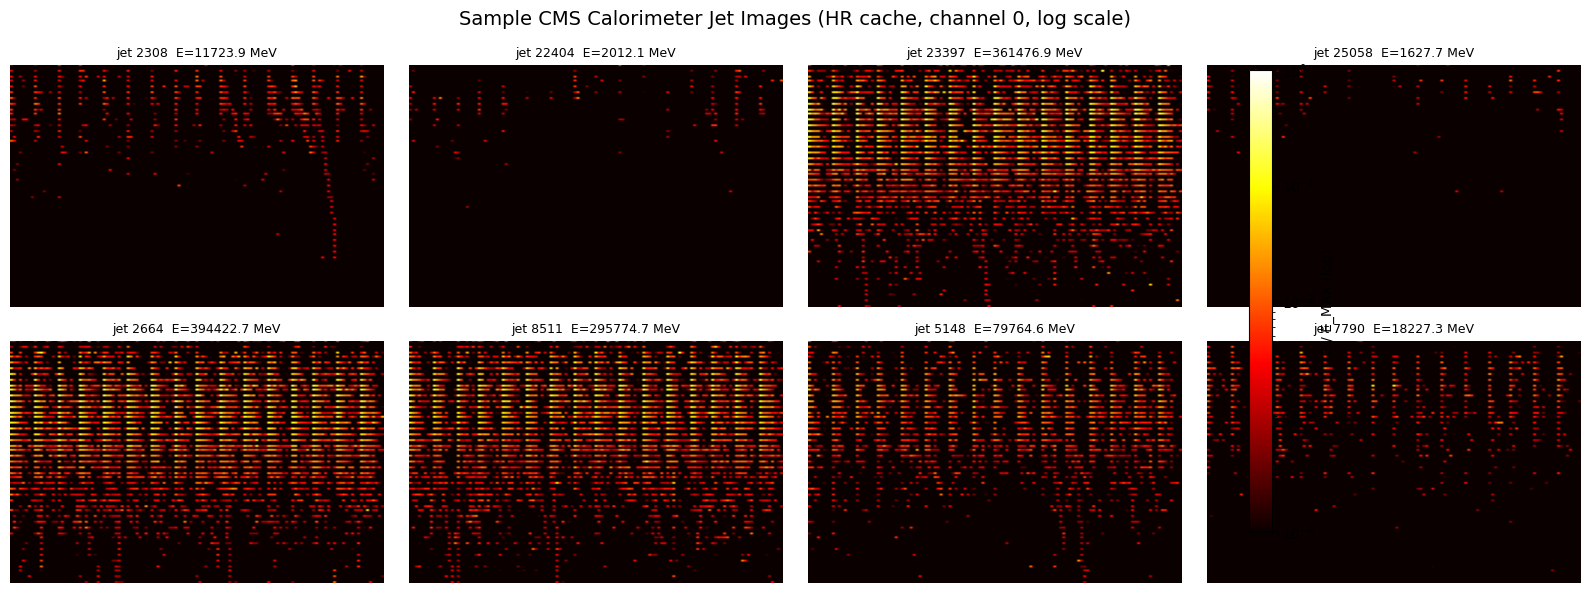

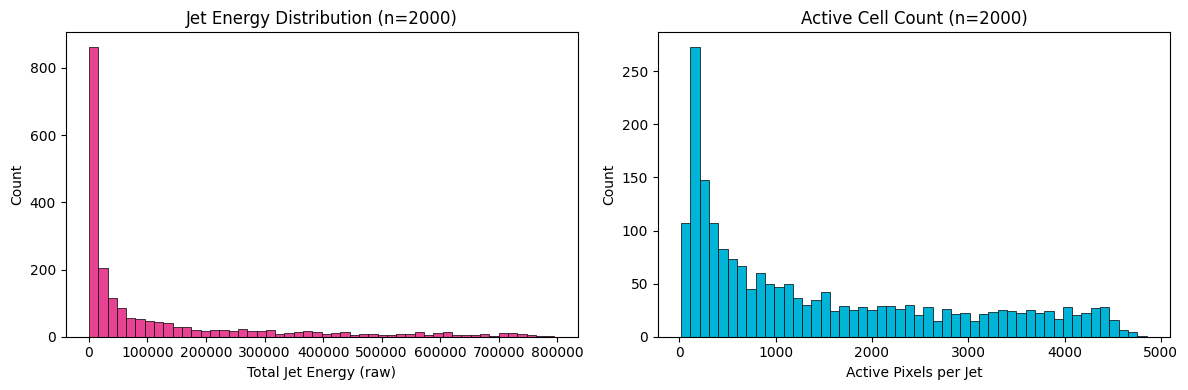

In [7]:
# ── Cell 5: Visualise sample jet images (from disk cache) ────────────────────
import numpy as np
hr_mm = np.load(cache_meta['hr_path'], mmap_mode='r')   # (N, C, 125,125) memmap
lr_mm = np.load(cache_meta['lr_path'], mmap_mode='r')   # (N, C, 64, 64)

N_SHOW = 8
sel = np.random.choice(N, N_SHOW, replace=False)

fig, axes = plt.subplots(2, N_SHOW // 2, figsize=(16, 6))
fig.suptitle('Sample CMS Calorimeter Jet Images (HR cache, channel 0, log scale)', fontsize=14)
for i, ax in enumerate(axes.flat):
    img = np.clip(hr_mm[sel[i], 0], 1e-6, None)
    im = ax.imshow(img, cmap='hot', norm=LogNorm(vmin=1e-4, vmax=1.0), aspect='auto')
    ax.set_title(f'jet {sel[i]}  E={energies_raw[sel[i],0]:.1f} MeV', fontsize=9)
    ax.axis('off')
fig.colorbar(im, ax=axes, label='E / E_MAX (log)')
plt.tight_layout(); plt.show()

# Energy / active-cell distributions on a memmapped subset (no full load).
stat_n = min(2000, N)
ss = np.sort(np.random.choice(N, stat_n, replace=False))
hr_sub = np.asarray(hr_mm[ss])     # pages in ~2000 HR images (~125 MB)
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
ax1.hist((hr_sub * E_MAX).sum(axis=(1,2,3)), bins=50, color='#e84393', edgecolor='k', linewidth=0.5)
ax1.set_xlabel('Total Jet Energy (raw)'); ax1.set_ylabel('Count')
ax1.set_title(f'Jet Energy Distribution (n={stat_n})')
ax2.hist((hr_sub > 0).sum(axis=(1,2,3)), bins=50, color='#00b4d8', edgecolor='k', linewidth=0.5)
ax2.set_xlabel('Active Pixels per Jet'); ax2.set_ylabel('Count')
ax2.set_title(f'Active Cell Count (n={stat_n})')
plt.tight_layout(); plt.show()


---
## 2 · Point Cloud Representation

**Core idea:** A calorimeter image is just a discretised point cloud.  
Each non-zero pixel at `(i, j)` maps to a physical coordinate `(η, φ)` with deposited energy `E`.  
This is exact — no information loss — and naturally handles **zero suppression**  
(CMS hardware sets E < threshold to exactly 0; we simply skip those points).

In [8]:
# ── Cell 6: Image ↔ Point Cloud conversion ────────────────────────────────────

def image_to_pointcloud(img: np.ndarray,
                        zero_suppression_threshold: float = 1e-6,
                        max_points: int = 1024) -> np.ndarray:
    """
    Convert a (C, H, W) image to a point cloud array of shape (N_active, 2 + C).
    Each row is [eta_norm, phi_norm, e_ch0, e_ch1, ...] — coordinates in [-1, 1].

    Resolution invariant: works for ANY H×W grid.
    Zero suppression: pixels below threshold are dropped.
    """
    C, H, W = img.shape
    # Grid of (η, φ) coordinates normalised to [-1, 1]
    eta_coords = np.linspace(-1, 1, H)   # row → η axis
    phi_coords = np.linspace(-1, 1, W)   # col → φ axis
    ETA, PHI = np.meshgrid(eta_coords, phi_coords, indexing='ij')  # (H, W)

    # Active pixel mask: at least one channel above threshold
    energy_sum = img.sum(axis=0)  # (H, W)
    mask = energy_sum > zero_suppression_threshold   # (H, W)

    eta_active = ETA[mask]           # (N_active,)
    phi_active = PHI[mask]           # (N_active,)
    e_active   = img[:, mask].T      # (N_active, C)

    points = np.concatenate([eta_active[:, None],
                              phi_active[:, None],
                              e_active], axis=-1)  # (N_active, 2+C)

    # Pad/truncate to max_points for batching
    if len(points) >= max_points:
        # Keep highest-energy points
        order = np.argsort(points[:, 2])[::-1][:max_points]
        points = points[order]
    else:
        pad = np.zeros((max_points - len(points), 2 + C), dtype=np.float32)
        points = np.concatenate([points, pad], axis=0)

    return points.astype(np.float32)


def pointcloud_to_image(points: np.ndarray,
                        target_H: int,
                        target_W: int,
                        C: int = 1,
                        aggregation: str = 'sum') -> np.ndarray:
    """
    Rasterise a point cloud (N, 2+C) → image (C, H, W) at any resolution.

    Coordinates in [-1, 1] are mapped to pixel indices via rounding.
    aggregation: 'sum' or 'mean' for deposits in the same pixel.

    This is the exact inverse of image_to_pointcloud — resolution invariant.
    """
    img = np.zeros((C, target_H, target_W), dtype=np.float32)
    count = np.zeros((target_H, target_W), dtype=np.float32)

    eta = points[:, 0]  # [-1, 1]
    phi = points[:, 1]  # [-1, 1]
    energies = points[:, 2:2+C]  # (N, C)

    # Map [-1,1] → pixel index [0, H-1] / [0, W-1] with rounding (buffer rounding)
    i_idx = np.clip(np.round((eta + 1) / 2 * (target_H - 1)).astype(int), 0, target_H - 1)
    j_idx = np.clip(np.round((phi + 1) / 2 * (target_W - 1)).astype(int), 0, target_W - 1)

    for n in range(len(points)):
        if energies[n].sum() == 0:  # skip padding
            continue
        img[:, i_idx[n], j_idx[n]] += energies[n]
        count[i_idx[n], j_idx[n]]  += 1

    if aggregation == 'mean':
        mask = count > 0
        img[:, mask] /= count[mask]

    return img


# Quick test on one jet — pull a single raw demo image from the HDF5 index.
from calo_dataset import sample_raw_images
_demo, _ = sample_raw_images(hdf5_index, E_MAX, 1, cell_shape=CELL_SHAPE,
                             showers_key=SHOWERS_KEY, seed=1)
test_img   = _demo[0]                           # (C, 45, 144)
_, dH, dW  = test_img.shape
test_pc    = image_to_pointcloud(test_img, max_points=1024)
recon_img  = pointcloud_to_image(test_pc, dH, dW, C=C)

print(f'Original image shape:   {test_img.shape}')
print(f'Point cloud shape:      {test_pc.shape}  (first 5 rows):')
print(f'  [η,    φ,    E0   ...]')
print(test_pc[:5])
print(f'Reconstruction error (L1): {np.abs(test_img - recon_img).mean():.6f}')

Original image shape:   (1, 45, 144)
Point cloud shape:      (1024, 3)  (first 5 rows):
  [η,    φ,    E0   ...]
[[-0.54545456 -0.35664335  0.39717016]
 [-0.6363636   0.3846154   0.25360867]
 [-0.59090906  0.25874126  0.2453876 ]
 [-0.59090906  0.3846154   0.23846489]
 [-0.59090906  0.5104895   0.23252513]]
Reconstruction error (L1): 0.000721


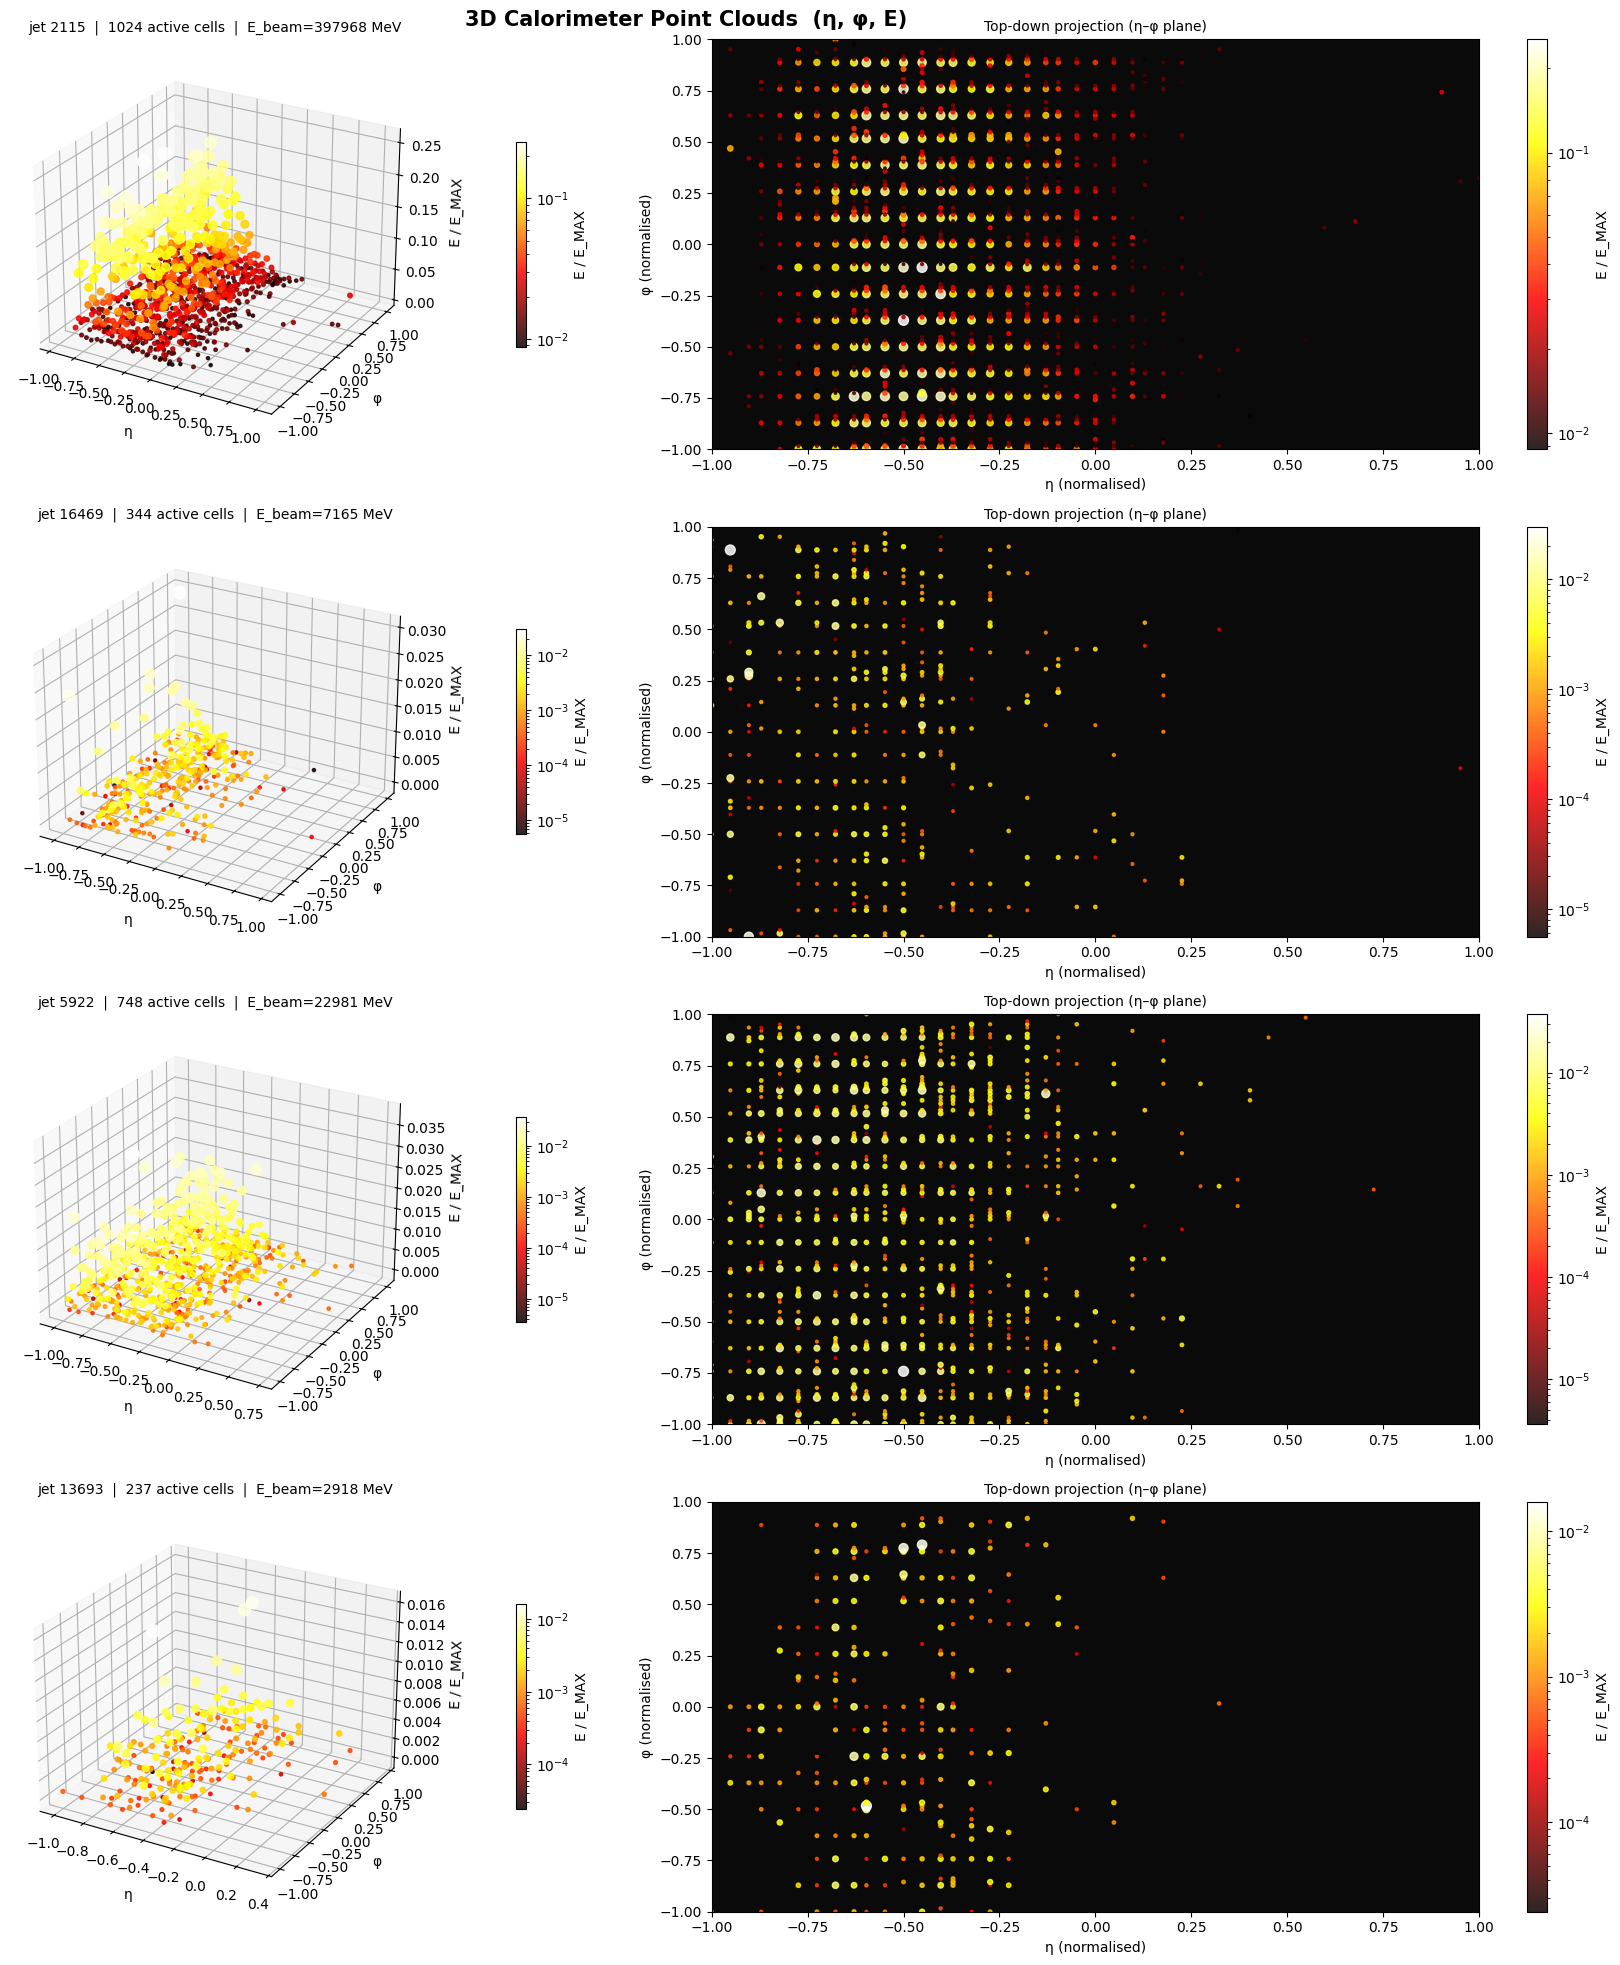

Plotted 4 jets — left: full 3-D (η, φ, E)  |  right: η–φ top-down projection


In [42]:
# ── Cell 6b: 3D Point Cloud Visualisation ────────────────────────────────────
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401
from matplotlib.colors import LogNorm
import matplotlib.cm as cm

# Read HR images from the disk cache (images_norm no longer exists).
hr_mm = np.load(cache_meta['hr_path'], mmap_mode='r')
N_JETS = 4
jet_indices = np.random.choice(N, N_JETS, replace=False)

fig = plt.figure(figsize=(20, 5 * N_JETS))
fig.suptitle('3D Calorimeter Point Clouds  (η, φ, E)', fontsize=15, fontweight='bold')

for row, ji in enumerate(jet_indices):
    pc = image_to_pointcloud(np.asarray(hr_mm[ji]), max_points=1024)

    # strip padding (zero-energy rows)
    active = pc[pc[:, 2] > 0]
    eta = active[:, 0]
    phi = active[:, 1]
    E   = active[:, 2]

    # ── left: 3D scatter, energy → color + size ──────────────────────────────
    ax3d = fig.add_subplot(N_JETS, 2, row * 2 + 1, projection='3d')

    E_norm = (E - E.min()) / (E.max() - E.min() + 1e-9)
    colors = cm.hot(E_norm)
    sizes  = 5 + 80 * E_norm          # bigger dot = more energy

    sc = ax3d.scatter(eta, phi, E, c=E, cmap='hot',
                      s=sizes, alpha=0.85, depthshade=True,
                      norm=LogNorm(vmin=E.min() + 1e-6, vmax=E.max()))

    ax3d.set_xlabel('η', labelpad=6)
    ax3d.set_ylabel('φ', labelpad=6)
    ax3d.set_zlabel('E / E_MAX', labelpad=6)
    ax3d.set_title(f'jet {ji}  |  {len(active)} active cells  |  E_beam={energies_raw[ji,0]:.0f} MeV',
                   fontsize=10)
    ax3d.view_init(elev=25, azim=-60)
    fig.colorbar(sc, ax=ax3d, shrink=0.5, pad=0.1, label='E / E_MAX')

    # ── right: top-down (η–φ) projection with energy as colour ──────────────
    ax2d = fig.add_subplot(N_JETS, 2, row * 2 + 2)
    sc2  = ax2d.scatter(eta, phi, c=E, cmap='hot', s=sizes * 0.6, alpha=0.85,
                        norm=LogNorm(vmin=E.min() + 1e-6, vmax=E.max()))
    ax2d.set_xlabel('η (normalised)')
    ax2d.set_ylabel('φ (normalised)')
    ax2d.set_title(f'Top-down projection (η–φ plane)', fontsize=10)
    ax2d.set_facecolor('#0a0a0a')
    ax2d.set_xlim(-1, 1); ax2d.set_ylim(-1, 1)
    fig.colorbar(sc2, ax=ax2d, label='E / E_MAX')

plt.tight_layout()
plt.show()
print(f'Plotted {N_JETS} jets — left: full 3-D (η, φ, E)  |  right: η–φ top-down projection')

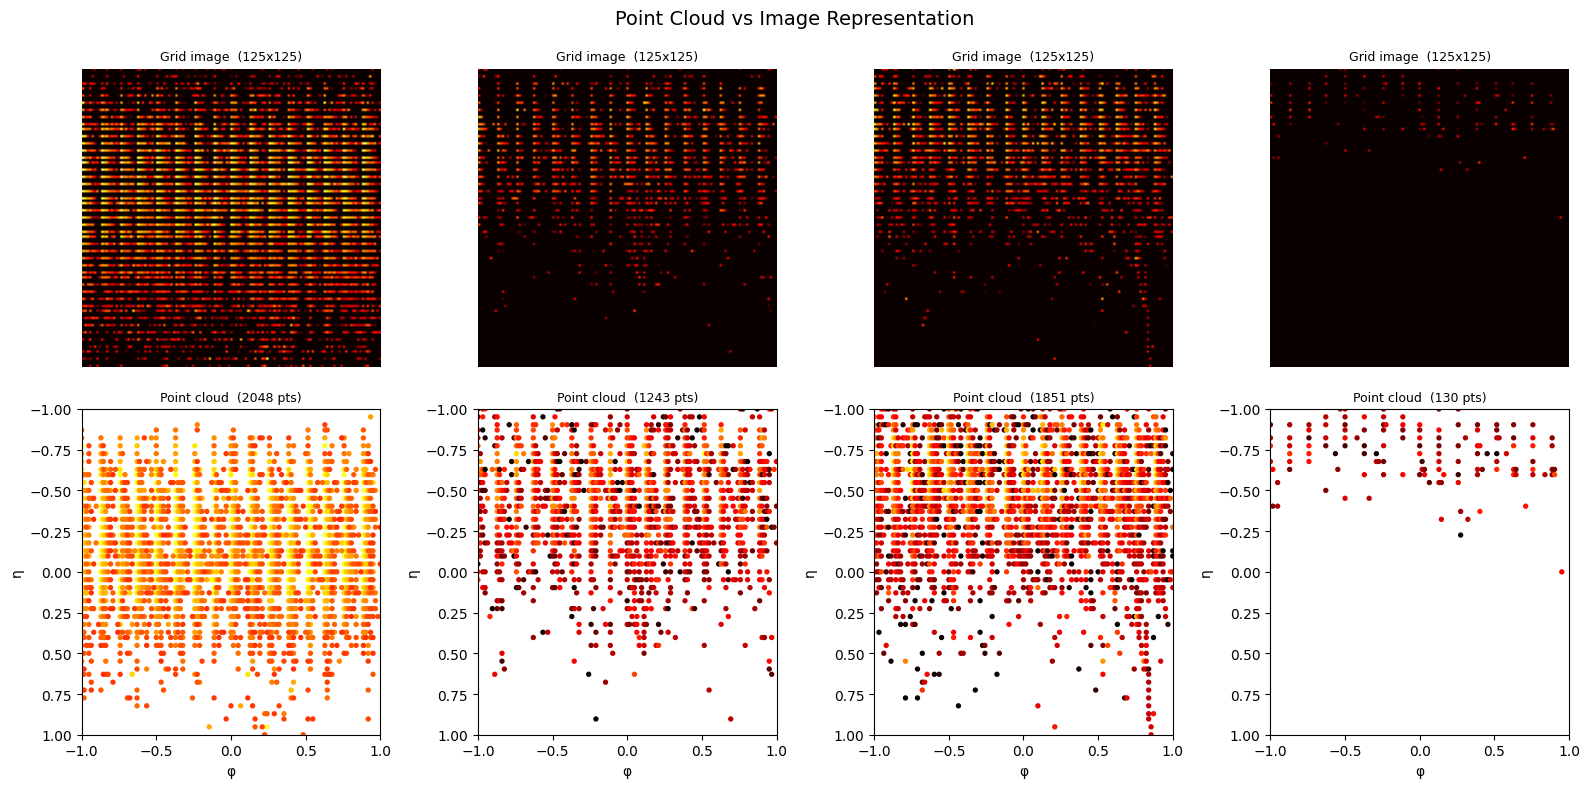

In [9]:
# ── Cell 7: Visualise point cloud for 4 jets ─────────────────────────────────
hr_mm = np.load(cache_meta['hr_path'], mmap_mode='r')   # HR images from disk cache
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
fig.suptitle('Point Cloud vs Image Representation', fontsize=14)

for col in range(4):
    img_3d = np.asarray(hr_mm[col])   # (C, HR_H, HR_W)
    img = img_3d[0]                  # single channel
    pc     = image_to_pointcloud(img_3d, max_points=2048)

    # Active points only
    active = pc[pc[:, 2] > 0]

    # Image row
    axes[0, col].imshow(np.clip(img, 1e-6, None), cmap='hot',
                        norm=LogNorm(vmin=1e-4, vmax=1.0), aspect='equal')
    axes[0, col].set_title(f'Grid image  ({img.shape[0]}x{img.shape[1]})', fontsize=9)
    axes[0, col].axis('off')

    # Point cloud scatter row
    sc = axes[1, col].scatter(active[:, 1], active[:, 0],
                               c=active[:, 2], cmap='hot',
                               s=8, norm=LogNorm(vmin=1e-4, vmax=1.0))
    axes[1, col].set_xlim(-1, 1); axes[1, col].set_ylim(-1, 1)
    axes[1, col].set_title(f'Point cloud  ({len(active)} pts)', fontsize=9)
    axes[1, col].set_xlabel('φ'); axes[1, col].set_ylabel('η')
    axes[1, col].invert_yaxis()

plt.tight_layout()
plt.show()

---
## 3 · Multi-Scale Downsampling Ladder

Your mentor's exact resolution scheme:  `256 × 256 → 125 × 125 → 64 × 64`

This simulates the CMS detector readout pipeline:
- **Buffer rounding** — coordinates are rounded to the nearest pixel in the lower-res grid
- **Aggregation** — multiple HR deposits that round to the same LR pixel are summed  
- **Zero suppression** — deposits below hardware threshold are zeroed out

Key insight: this is **lossless in principle** but **lossy in practice** because rounding  
merges fine-grained deposits into coarser bins — exactly what SR must invert.

In [10]:
# ── Cell 8: Resolution ladder — downsample via point cloud rounding ───────────

ZERO_SUPPRESSION_THRESHOLD = 1e-3   # Simulates CMS hardware threshold (tune as needed)

RESOLUTION_LADDER = {
    'HR':  (256, 256),   # Simulation truth (pad original to this if needed)
    'MR':  (125, 125),   # Intermediate
    'LR':  (64,  64),    # Lowest resolution — model input
}


def apply_zero_suppression(img: np.ndarray, threshold: float) -> np.ndarray:
    """Zero out pixels below hardware threshold. Physics-exact."""
    out = img.copy()
    out[out < threshold] = 0.0
    return out


def downsample_via_pointcloud(img: np.ndarray,
                               target_H: int,
                               target_W: int,
                               zero_thresh: float = ZERO_SUPPRESSION_THRESHOLD) -> np.ndarray:
    """
    Downsample (C,H,W) image to (C, target_H, target_W) via point cloud rounding.

    Steps:
      1. Extract point cloud (zero-suppress & convert to (η, φ, E))
      2. Round (η, φ) coordinates to nearest pixel in target grid
      3. Sum energy deposits in each target pixel (aggregation)
      4. Apply zero suppression again on output

    This is resolution invariant — target grid can be anything.
    """
    C, H, W = img.shape
    pc  = image_to_pointcloud(img, zero_suppression_threshold=zero_thresh, max_points=H*W)
    out = pointcloud_to_image(pc, target_H, target_W, C=C, aggregation='sum')
    out = apply_zero_suppression(out, zero_thresh)
    return out


def pad_to_resolution(img: np.ndarray, target_H: int, target_W: int) -> np.ndarray:
    """
    Resize (C, H, W) → (C, target_H, target_W) via point cloud rounding.
    Works whether the image is smaller (upscale) or larger (downscale) than target.
    """
    C, H, W = img.shape
    if H == target_H and W == target_W:
        return img
    # If larger in any dimension, downsample via point cloud (lossless routing)
    if H > target_H or W > target_W:
        return downsample_via_pointcloud(img, target_H, target_W, zero_thresh=0.0)
    # If smaller, center-pad with zeros
    out = np.zeros((C, target_H, target_W), dtype=img.dtype)
    pad_h = (target_H - H) // 2
    pad_w = (target_W - W) // 2
    out[:, pad_h:pad_h+H, pad_w:pad_w+W] = img
    return out


# ── Demo: multi-scale pyramid for one jet ────────────────────────────────────
from calo_dataset import sample_raw_images
_demo, _ = sample_raw_images(hdf5_index, E_MAX, 1, cell_shape=CELL_SHAPE,
                             showers_key=SHOWERS_KEY, seed=2)
sample = _demo[0]   # (C, 45, 144)
HR_H, HR_W = RESOLUTION_LADDER['HR']

# Lift to HR if dataset is already at a different resolution
sample_hr = pad_to_resolution(sample, HR_H, HR_W)
sample_mr = downsample_via_pointcloud(sample_hr, *RESOLUTION_LADDER['MR'])
sample_lr = downsample_via_pointcloud(sample_hr, *RESOLUTION_LADDER['LR'])

print('Resolution Ladder:')
for name, arr in [('HR (256)', sample_hr), ('MR (125)', sample_mr), ('LR (64)', sample_lr)]:
    sparsity = (arr == 0).mean()
    e_total  = arr.sum()
    print(f'  {name:10s}  shape={arr.shape}  sparsity={sparsity:.2%}  E_total={e_total:.4f}')

Resolution Ladder:
  HR (256)    shape=(1, 256, 256)  sparsity=98.28%  E_total=3.7128
  MR (125)    shape=(1, 125, 125)  sparsity=97.38%  E_total=3.5119
  LR (64)     shape=(1, 64, 64)  sparsity=94.95%  E_total=3.5119


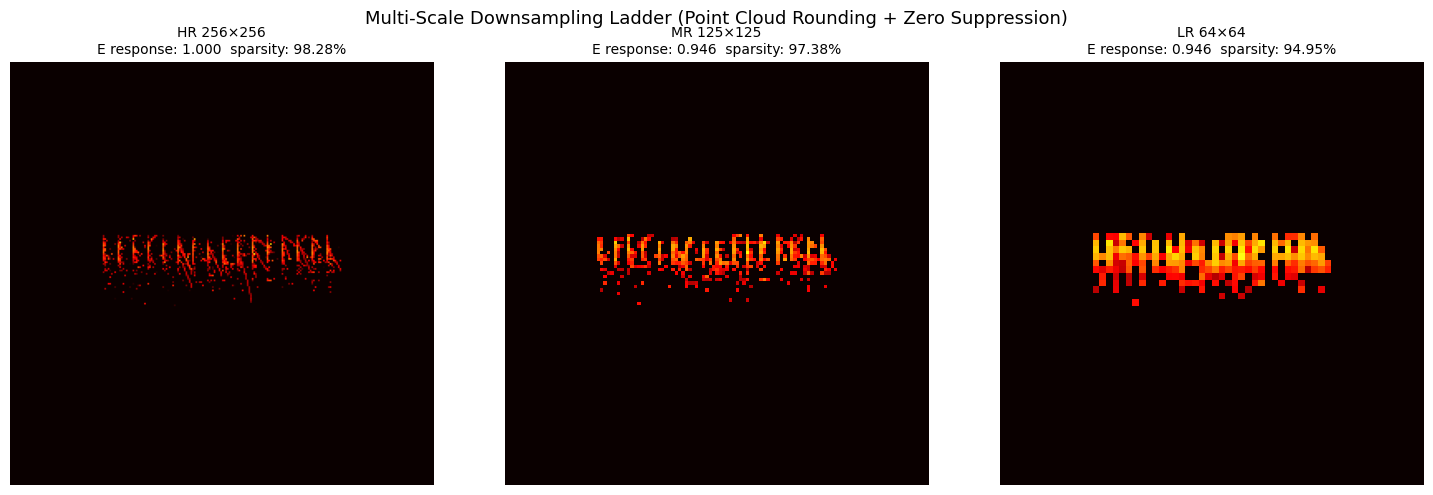

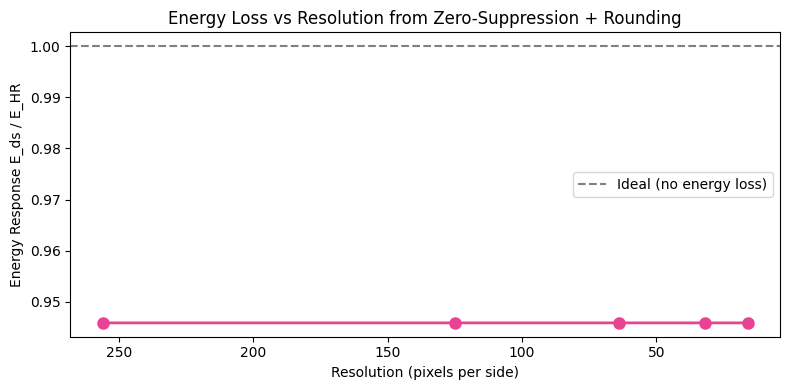

In [44]:
# ── Cell 9: Visualise the multi-scale pyramid ─────────────────────────────────
scales = {'HR 256×256': sample_hr, 'MR 125×125': sample_mr, 'LR 64×64': sample_lr}

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Multi-Scale Downsampling Ladder (Point Cloud Rounding + Zero Suppression)', fontsize=13)

for ax, (title, arr) in zip(axes, scales.items()):
    display = np.clip(arr[0], 1e-6, None)
    ax.imshow(display, cmap='hot', norm=LogNorm(vmin=1e-4, vmax=1.0), aspect='equal')
    e_response = arr.sum() / (sample_hr.sum() + 1e-8)
    ax.set_title(f'{title}\nE response: {e_response:.3f}  sparsity: {(arr==0).mean():.2%}', fontsize=10)
    ax.axis('off')

plt.tight_layout()
plt.show()

# Energy response vs resolution
resolutions = [256, 125, 64, 32, 16]
e_responses = []
for r in resolutions:
    ds = downsample_via_pointcloud(sample_hr, r, r)
    e_responses.append(ds.sum() / (sample_hr.sum() + 1e-8))

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(resolutions, e_responses, 'o-', color='#e84393', linewidth=2, markersize=8)
ax.axhline(1.0, color='gray', linestyle='--', label='Ideal (no energy loss)')
ax.set_xlabel('Resolution (pixels per side)'); ax.set_ylabel('Energy Response E_ds / E_HR')
ax.set_title('Energy Loss vs Resolution from Zero-Suppression + Rounding')
ax.legend(); ax.invert_xaxis(); plt.tight_layout(); plt.show()

---
## 4 · PyTorch Dataset — Resolution Invariant

The dataset returns **(LR point cloud, HR image, query coordinates)**  
so the model is **never** given a fixed grid — it must learn to predict energy  
at *any* queried (η, φ) location.

In [11]:
# ── Cell 10: PyTorch Dataset (disk-cache backed, fast, MPS-ready) ─────────────
# Reads precomputed HR+LR from the memmapped cache, so __getitem__ only does the
# near-free phi-flip + LR pointcloud + query sampling (~0.5 ms vs ~31 ms before).
import importlib, calo_dataset
importlib.reload(calo_dataset)
from calo_dataset import (CalorimeterSRDataset, image_to_pointcloud,
                          pointcloud_to_image, downsample_via_pointcloud,
                          pad_to_resolution, apply_zero_suppression)

# ── Train/val split over cache positions [0, N) ──────────────────────────────
TRAIN_FRAC = 0.85
N_TRAIN    = int(N * TRAIN_FRAC)
perm       = np.random.permutation(N)
train_pos, val_pos = perm[:N_TRAIN], perm[N_TRAIN:]

common = dict(hr_res=HR_RES, lr_res=LR_RES, max_points=512, n_query=512, nonzero_frac=0.3,
              zero_thresh=ZERO_SUPPRESSION_THRESHOLD, cache=cache_meta)
train_dataset = CalorimeterSRDataset(beam_energies=energies_raw[train_pos],
                                     cache_rows=train_pos, augment=True,  **common)
val_dataset   = CalorimeterSRDataset(beam_energies=energies_raw[val_pos],
                                     cache_rows=val_pos,   augment=False, **common)

# Bigger batch + more workers — the cache makes data prep cheap, so we can feed
# the (otherwise-idle) MPS GPU much faster.
BATCH_SIZE  = 64
NUM_WORKERS = 8
loader_kwargs = dict(batch_size=BATCH_SIZE, num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
if NUM_WORKERS > 0:
    loader_kwargs.update(persistent_workers=True, prefetch_factor=2)

train_loader = DataLoader(train_dataset, shuffle=True,  **loader_kwargs)
val_loader   = DataLoader(val_dataset,   shuffle=False, **loader_kwargs)

print(f'Train samples: {len(train_dataset)}  |  Val samples: {len(val_dataset)}')
print(f'DataLoader: batch={BATCH_SIZE}, num_workers={NUM_WORKERS}, '
      f'{len(train_loader)} train / {len(val_loader)} val batches/epoch')
print('Backend: disk cache (memmapped HR+LR)')
batch = next(iter(train_loader))
for k, v in batch.items():
    print(f'  {k:12s}  {str(tuple(v.shape)):30s}  dtype={v.dtype}')


Train samples: 25500  |  Val samples: 4500
DataLoader: batch=64, num_workers=8, 399 train / 71 val batches/epoch
Backend: disk cache (memmapped HR+LR)


  lr_pc         (64, 512, 3)                    dtype=torch.float32
  hr_img        (64, 1, 125, 125)               dtype=torch.float32
  lr_img        (64, 1, 64, 64)                 dtype=torch.float32
  query_pts     (64, 512, 2)                    dtype=torch.float32
  query_e       (64, 512, 1)                    dtype=torch.float32
  beam_e        (64,)                           dtype=torch.float32


---
## 5 · Resolution-Invariant Model Architecture

```
PointNet Encoder                         INR Decoder (SIREN)
────────────────────────────             ─────────────────────────────────
LR point cloud (N, 2+C)                 z + query (η, φ)  →  E_pred
  │ per-point MLP                        │ sin activations
  │ max-pool (set aggregation)           │ 5-layer SIREN
  ▼                                      ▼
latent z (256-d)       ───────────►   Predicted E at query point
```

**Why this is resolution invariant:**
- PointNet operates on a *set* of points — order and count don't matter
- INR takes continuous (η, φ) coordinates → output is defined at *any* point in space
- To get a 64×64 image: query on a 64×64 grid; for 1M points: query on 1M random coords
- No conv layers with fixed kernels tied to a particular image size

In [12]:
# ── Cell 11: PointNet Encoder ─────────────────────────────────────────────────

class PointNetEncoder(nn.Module):
    """Lightweight PointNet: (B, N, 2+C) -> (B, latent). Perm- & res-invariant."""

    def __init__(self, in_features: int, latent_dim: int = 256):
        super().__init__()
        self.in_features = in_features
        self.mlp = nn.Sequential(
            nn.Conv1d(in_features, 64, 1),  nn.BatchNorm1d(64),  nn.ReLU(),
            nn.Conv1d(64,  128, 1),          nn.BatchNorm1d(128), nn.ReLU(),
            nn.Conv1d(128, 256, 1),          nn.BatchNorm1d(256), nn.ReLU(),
        )
        self.head = nn.Sequential(
            nn.Linear(256, 256), nn.LayerNorm(256), nn.GELU(),
            nn.Linear(256, latent_dim),
        )

    def forward(self, pc: torch.Tensor) -> torch.Tensor:
        x = pc.transpose(1, 2)
        x = self.mlp(x)
        x = x.max(dim=-1).values
        return self.head(x)


# ── Cell 12: GATED decoder — SIREN magnitude + separate ReLU occupancy ─────────

class SineLayer(nn.Module):
    """SIREN layer: y = sin(omega_0 * Wx)."""

    def __init__(self, in_f: int, out_f: int, omega_0: float = 30.0, is_first: bool = False):
        super().__init__()
        self.omega_0 = omega_0
        self.linear  = nn.Linear(in_f, out_f)
        with torch.no_grad():
            if is_first:
                self.linear.weight.uniform_(-1 / in_f, 1 / in_f)
            else:
                b = math.sqrt(6 / in_f) / omega_0
                self.linear.weight.uniform_(-b, b)

    def forward(self, x):
        return torch.sin(self.omega_0 * self.linear(x))


class INRDecoder(nn.Module):
    """
    Gated decoder for SPARSE calorimeter data. Two independent pathways:

      • MAGNITUDE : SIREN trunk -> softplus  (smooth energy values)
      • OCCUPANCY : SEPARATE ReLU-MLP on (coord, latent) -> sigmoid  ("is there a hit?")

      energy = sigmoid(occ_logit) * magnitude

    Why two trunks: sharing the high-frequency SIREN features made the occupancy
    head stall at chance (l_occ≈0.69) and collapse to "off everywhere" → black
    output. A plain ReLU path learns a clean on/off boundary independently.

    forward(z, q)                    -> energy (B, N_q, C)
    forward(z, q, return_parts=True) -> (energy, occ_logit, mag)
    """

    def __init__(self, latent_dim: int = 256, hidden_dim: int = 256,
                 n_layers: int = 5, out_C: int = 1, omega_0: float = 30.0):
        super().__init__()
        self.out_C  = out_C
        self.first  = SineLayer(2 + latent_dim, hidden_dim, omega_0, is_first=True)
        self.hidden = nn.ModuleList([
            SineLayer(hidden_dim, hidden_dim, omega_0) for _ in range(n_layers - 2)
        ])
        self.mag_head = nn.Linear(hidden_dim, out_C)
        nn.init.constant_(self.mag_head.bias, 0.0)

        # Fourier positional encoding of (eta, phi) so the ReLU occ-net can
        # represent SHARP spatial boundaries. Raw 2D coords through a ReLU MLP
        # underfit fine spatial detail (a cause of the frozen-at-ln2 gate).
        self.n_fourier = 8
        freqs = 2.0 ** torch.arange(self.n_fourier).float() * math.pi   # (n_fourier,)
        self.register_buffer('occ_freqs', freqs)
        occ_in = latent_dim + 2 + 2 * 2 * self.n_fourier   # latent + raw coords + sin/cos
        self.occ_net = nn.Sequential(
            nn.Linear(occ_in, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim), nn.ReLU(),
            nn.Linear(hidden_dim, out_C),
        )
        nn.init.constant_(self.occ_net[-1].bias, -2.0)   # default "mostly empty"

    def _occ_features(self, query, z_exp):
        # query: (B, N_q, 2); z_exp: (B, N_q, latent)
        # Fourier features: [sin(f*x), cos(f*x)] for each freq, each coord.
        proj = query.unsqueeze(-1) * self.occ_freqs           # (B, N_q, 2, n_fourier)
        proj = proj.flatten(-2)                               # (B, N_q, 2*n_fourier)
        ff = torch.cat([torch.sin(proj), torch.cos(proj)], dim=-1)  # (B,N_q,4*n_fourier)
        return torch.cat([query, ff, z_exp], dim=-1)

    def forward(self, z, query, return_parts: bool = False):
        B, N_q, _ = query.shape
        z_exp = z.unsqueeze(1).expand(-1, N_q, -1)
        inp = torch.cat([query, z_exp], dim=-1)           # (B, N_q, 2+latent)

        x = self.first(inp)
        for layer in self.hidden:
            x = layer(x)
        mag = F.softplus(self.mag_head(x))                # (B, N_q, C)

        occ_logit = self.occ_net(self._occ_features(query, z_exp))  # (B, N_q, C)
        energy = torch.sigmoid(occ_logit) * mag
        if return_parts:
            return energy, occ_logit, mag
        return energy


# ── Cell 13: Full model ────────────────────────────────────────────────────────

# Occupancy threshold used at INFERENCE to produce a hard, sparse image. Pixels
# with sigmoid(occ) below this are forced to 0 (the soft gate alone leaves a faint
# floor everywhere). Tune on val: higher -> sparser. ~0.5 is the natural default.
OCC_THRESHOLD = 0.55

class ResolutionInvariantSR(nn.Module):
    """Encode LR point cloud -> latent z; decode at any (eta,phi) -> energy."""

    def __init__(self, C: int = 1, latent_dim: int = 256,
                 inr_hidden: int = 256, inr_layers: int = 5):
        super().__init__()
        self.C       = C
        self.encoder = PointNetEncoder(in_features=2 + C, latent_dim=latent_dim)
        self.decoder = INRDecoder(latent_dim=latent_dim, hidden_dim=inr_hidden,
                                  n_layers=inr_layers, out_C=C)

    def forward(self, lr_pc, query_pts, return_parts: bool = False):
        z = self.encoder(lr_pc)
        return self.decoder(z, query_pts, return_parts=return_parts)

    @torch.no_grad()
    def rasterise(self, lr_pc, target_H, target_W, occ_threshold: float = OCC_THRESHOLD):
        """Full image at ANY resolution, with a HARD occupancy gate for sparsity."""
        self.eval()
        B = lr_pc.shape[0]; dev = lr_pc.device
        eta = torch.linspace(-1, 1, target_H, device=dev)
        phi = torch.linspace(-1, 1, target_W, device=dev)
        ETA, PHI = torch.meshgrid(eta, phi, indexing='ij')
        grid = torch.stack([ETA.flatten(), PHI.flatten()], dim=-1).unsqueeze(0).expand(B, -1, -1)
        energy, occ_logit, _ = self.forward(lr_pc, grid, return_parts=True)
        # Hard gate: zero out low-occupancy pixels so the output is genuinely sparse.
        energy = torch.where(torch.sigmoid(occ_logit) > occ_threshold,
                             energy, torch.zeros_like(energy))
        return energy.transpose(1, 2).reshape(B, self.C, target_H, target_W)


# ── Instantiate & sanity check ────────────────────────────────────────────────
model = ResolutionInvariantSR(C=C, latent_dim=256, inr_hidden=256, inr_layers=5).to(DEVICE)
print(f'Total parameters: {sum(p.numel() for p in model.parameters()):,}')

dummy_pc    = torch.zeros(4, 512, 2 + C, device=DEVICE)
dummy_query = torch.rand(4, 256, 2, device=DEVICE) * 2 - 1
out = model(dummy_pc, dummy_query)
e, occ, mag = model(dummy_pc, dummy_query, return_parts=True)
print(f'Forward OK — energy {tuple(out.shape)}, occ {tuple(occ.shape)}, mag {tuple(mag.shape)}')
for res in [64, 125, 256]:
    print(f'  Rasterise {res}x{res}: {tuple(model.rasterise(dummy_pc, res, res).shape)}')


Total parameters: 579,074
Forward OK — energy (4, 256, 1), occ (4, 256, 1), mag (4, 256, 1)
  Rasterise 64x64: (4, 1, 64, 64)
  Rasterise 125x125: (4, 1, 125, 125)
  Rasterise 256x256: (4, 1, 256, 256)


---
## 6 · Physics-Aware Loss Functions

Three components (same philosophy as your existing GAN baseline, now applied to INR):

$$\mathcal{L} = \lambda_{\text{rec}} \cdot \mathcal{L}_{\text{L1}} + \lambda_{\text{phys}} \cdot \mathcal{L}_{\text{energy}} + \lambda_{\text{sparse}} \cdot \mathcal{L}_{\text{sparsity}}$$

| Loss | Formula | Physics reason |
|------|---------|---------------|
| **L1 reconstruction** | $|E_{pred} - E_{gt}|$ | Pixel-accurate deposit recovery |
| **Energy conservation** | $(\sum E_{pred} / \sum E_{gt} - 1)^2$ | Total jet energy must be preserved |
| **Sparsity (zero suppression)** | $\|\max(E_{pred} - \tau, 0) \cdot \mathbb{1}[E_{gt}=0]\|_1$ | Don't hallucinate deposits below threshold |

In [13]:
# ── Cell 14: Loss functions (gated, sparse-aware) ─────────────────────────────

class PhysicsAwareLoss(nn.Module):
    """
    Loss for the GATED decoder. Components:
      • occupancy (BCE) : sigmoid(occ_logit) should match (E_gt > thresh).
                          THIS is what lets the model output hard zeros — it
                          learns *where* energy is, not just how much.
      • weighted L1     : energy error, upweighting non-zero targets so the rare
                          real deposits aren't drowned by the ~95% empty pixels.
      • energy          : bounded |sum_pred - sum_gt| (total-energy scale).
    No explicit sparsity penalty — the occupancy gate handles sparsity directly.
    """

    def __init__(self,
                 lambda_rec:    float = 1.0,
                 lambda_energy: float = 1.0,
                 lambda_occ:    float = 3.0,
                 nonzero_weight: float = 20.0,
                 occ_pos_weight: float = 1.0,
                 zero_thresh:   float = ZERO_SUPPRESSION_THRESHOLD):
        super().__init__()
        self.lam_rec    = lambda_rec
        self.lam_energy = lambda_energy
        self.lam_occ    = lambda_occ
        self.alpha      = nonzero_weight
        self.occ_pos_w  = occ_pos_weight   # >1 favours recall (fire where energy is)
        self.thresh     = zero_thresh

    def forward(self, E_pred, E_gt, occ_logit=None):
        target_occ = (E_gt > self.thresh).float()         # (B, N_q, C)

        # Occupancy BCE (the key term for sparsity).
        if occ_logit is not None:
            pw = torch.tensor(self.occ_pos_w, device=occ_logit.device)
            l_occ = F.binary_cross_entropy_with_logits(occ_logit, target_occ, pos_weight=pw)
        else:
            l_occ = torch.zeros((), device=E_pred.device)

        # Magnitude L1: emphasise ACTIVE pixels (where E_gt>thresh) so the loss
        # isn't saturated by the trivial ~95% zeros. A small all-pixel term keeps
        # the background honest.
        active = target_occ
        n_act = active.sum().clamp(min=1)
        l_rec_active = ((E_pred - E_gt).abs() * active).sum() / n_act
        l_rec_all    = (E_pred - E_gt).abs().mean()
        l_rec = l_rec_active + 0.1 * l_rec_all

        # Bounded energy-conservation term.
        E_sum_pred = E_pred.sum(dim=(1, 2)); E_sum_gt = E_gt.sum(dim=(1, 2))
        l_energy = (E_sum_pred - E_sum_gt).abs().mean()

        total = (self.lam_rec    * l_rec +
                 self.lam_energy * l_energy +
                 self.lam_occ    * l_occ)

        with torch.no_grad():
            response = (E_sum_pred / (E_sum_gt + 1e-6)).clamp(0, 10).mean()
            # occupancy accuracy on non-zero targets (recall) — are we firing where we should?
            if occ_logit is not None:
                pred_hit = (torch.sigmoid(occ_logit) > 0.5).float()
                tp = (pred_hit * target_occ).sum()
                recall    = tp / target_occ.sum().clamp(min=1)
                precision = tp / pred_hit.sum().clamp(min=1)
            else:
                recall = precision = torch.zeros(())

        return {
            'loss':     total,
            'l_rec':    l_rec.item(),
            'l_energy': l_energy.item(),
            'l_occ':    l_occ.item(),
            'response':  response.item(),
            'recall':    float(recall),
            'precision': float(precision),
        }


criterion = PhysicsAwareLoss(lambda_rec=1.0, lambda_energy=0.2, lambda_occ=3.0,
                             nonzero_weight=10.0, occ_pos_weight=2.0)
print('Loss function initialised OK (gated: BCE occupancy + weighted L1 + energy)')


Loss function initialised OK (gated: BCE occupancy + weighted L1 + energy)


---
## 7 · Training

In [15]:
# ── Cell 15: Training loop ────────────────────────────────────────────────────
import os, time
from tqdm.auto import tqdm

EPOCHS    = 10            # increase to 100+ for full training
LR        = 1e-4
CLIP_GRAD = 1.0
LOG_EVERY = 1            # print a summary line every N epochs
WARMUP    = 4            # linear LR warmup epochs (SIREN benefits from warmup)

# Param groups: the ReLU occupancy net learns at a HIGHER LR than the SIREN trunk.
# SIREN's small init + omega_0=30 needs a low LR, which was starving the occ net
# (its BCE was frozen at ln2). Decoupling lets each learn at its own pace.
occ_params, base_params = [], []
for name, p in model.named_parameters():
    (occ_params if 'occ_net' in name else base_params).append(p)
optimizer = torch.optim.AdamW([
    {'params': base_params, 'lr': LR},
    {'params': occ_params,  'lr': 1e-3},
], weight_decay=1e-4)

# Warmup (linear) -> cosine anneal. Warmup stabilises the SIREN start.
def lr_lambda(epoch):
    if epoch < WARMUP:
        return (epoch + 1) / WARMUP
    import math as _m
    prog = (epoch - WARMUP) / max(1, EPOCHS - WARMUP)
    return 0.5 * (1 + _m.cos(_m.pi * prog))   # cosine 1 -> 0
scheduler = torch.optim.lr_scheduler.LambdaLR(optimizer, lr_lambda)

history = {k: [] for k in ['train_loss', 'val_loss', 'val_response',
                           'train_l_rec', 'train_l_occ', 'val_l_occ',
                           'val_recall', 'val_precision']}


def run_epoch(loader, train: bool, desc: str = '') -> dict:
    model.train(train)
    ctx    = torch.enable_grad() if train else torch.no_grad()
    totals = {k: 0.0 for k in ['loss', 'l_rec', 'l_energy', 'l_occ', 'response', 'recall', 'precision']}
    n      = len(loader)

    pbar = tqdm(loader, desc=desc, leave=False, total=n)
    with ctx:
        for batch in pbar:
            lr_pc     = batch['lr_pc'].to(DEVICE, non_blocking=True)      # (B, N, 2+C)
            query_pts = batch['query_pts'].to(DEVICE, non_blocking=True)  # (B, N_q, 2)
            query_e   = batch['query_e'].to(DEVICE, non_blocking=True)    # (B, N_q, C)

            E_pred, occ_logit, _ = model(lr_pc, query_pts, return_parts=True)
            result = criterion(E_pred, query_e, occ_logit)

            if train:
                optimizer.zero_grad()
                result['loss'].backward()
                nn.utils.clip_grad_norm_(model.parameters(), CLIP_GRAD)
                optimizer.step()

            for k in totals:
                totals[k] += result[k] if isinstance(result[k], float) else result[k].item()

            pbar.set_postfix(loss=f"{result['loss'].item():.4f}")

    return {k: v / n for k, v in totals.items()}


# ── Checkpoint path (works on Mac — make the dir) ────────────────────────────
CKPT_DIR  = './checkpoints'
os.makedirs(CKPT_DIR, exist_ok=True)
CKPT_PATH = os.path.join(CKPT_DIR, 'best_sr_model.pt')

# ── Confirm the model really is on the target device ─────────────────────────
assert next(model.parameters()).device.type == DEVICE, \
    f'Model is on {next(model.parameters()).device}, expected {DEVICE}'
print(f'Training on {DEVICE}  |  {len(train_loader)} batches/epoch  '
      f'|  checkpoint -> {CKPT_PATH}')

best_val_loss = float('inf')
for epoch in range(1, EPOCHS + 1):
    t0 = time.time()
    t_metrics = run_epoch(train_loader, train=True,  desc=f'Epoch {epoch}/{EPOCHS} [train]')
    v_metrics = run_epoch(val_loader,   train=False, desc=f'Epoch {epoch}/{EPOCHS} [val]')
    scheduler.step()
    dt = time.time() - t0

    history['train_loss'].append(t_metrics['loss'])
    history['val_loss'].append(v_metrics['loss'])
    history['val_response'].append(v_metrics['response'])
    history['train_l_rec'].append(t_metrics['l_rec'])
    history['train_l_occ'].append(t_metrics['l_occ'])
    history['val_l_occ'].append(v_metrics['l_occ'])
    history['val_recall'].append(v_metrics['recall'])
    history['val_precision'].append(v_metrics['precision'])

    star = ''
    if v_metrics['loss'] < best_val_loss:
        best_val_loss = v_metrics['loss']
        torch.save({'model': model.state_dict(),
                    'epoch': epoch,
                    'val_loss': best_val_loss}, CKPT_PATH)
        star = ' ★'

    if epoch % LOG_EVERY == 0 or epoch == 1 or epoch == EPOCHS:
        bps = len(train_loader) / dt
        print(f'Epoch {epoch:3d}/{EPOCHS}  '
              f'train={t_metrics["loss"]:.4f}  val={v_metrics["loss"]:.4f}  '
              f'| l_rec={t_metrics["l_rec"]:.4f} l_occ={t_metrics["l_occ"]:.4f} '
              f'resp={v_metrics["response"]:.3f} recall={v_metrics["recall"]:.3f}  '
              f'lr={scheduler.get_last_lr()[0]:.1e}  {dt:4.0f}s{star}')

print(f'\nBest val loss: {best_val_loss:.5f}  |  saved to {CKPT_PATH}')

Training on mps  |  399 batches/epoch  |  checkpoint -> ./checkpoints/best_sr_model.pt


Epoch   1/10  train=2.1024  val=1.3012  | l_rec=0.0101 l_occ=0.6503 resp=1.054 recall=0.817  lr=5.0e-05    40s ★


Epoch   2/10  train=1.2650  val=1.1661  | l_rec=0.0108 l_occ=0.3873 resp=0.965 recall=0.900  lr=7.5e-05    35s ★


Epoch   3/10  train=1.1908  val=1.1477  | l_rec=0.0109 l_occ=0.3665 resp=1.213 recall=0.893  lr=1.0e-04    41s ★


Epoch   4/10  train=1.1619  val=1.1271  | l_rec=0.0107 l_occ=0.3617 resp=1.055 recall=0.876  lr=1.0e-04    50s ★


...

Epoch   6/10  train=1.1253  val=1.1084  | l_rec=0.0103 l_occ=0.3554 resp=1.017 recall=0.884  lr=7.5e-05    60s ★


Epoch   7/10  train=1.1160  val=1.1392  | l_rec=0.0103 l_occ=0.3534 resp=1.221 recall=0.914  lr=5.0e-05    63s


Epoch   8/10  train=1.1089  val=1.1048  | l_rec=0.0102 l_occ=0.3518 resp=0.975 recall=0.869  lr=2.5e-05    64s ★


Epoch   9/10  train=1.0995  val=1.1049  | l_rec=0.0100 l_occ=0.3502 resp=1.119 recall=0.883  lr=6.7e-06    64s


Epoch  10/10  train=1.0939  val=1.0917  | l_rec=0.0098 l_occ=0.3495 resp=0.984 recall=0.873  lr=0.0e+00    64s ★

Best val loss: 1.09172  |  saved to ./checkpoints/best_sr_model.pt


In [26]:
FIGURES_DIR = '/Users/rajveerrathod/Work/Google_Summer_of_code/GAN/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)

def savefig(fig, name, dpi=150):
    """Save a matplotlib figure into FIGURES_DIR as <name>.png."""
    path = os.path.join(FIGURES_DIR, f'{name}.png')
    fig.savefig(path, dpi=dpi, bbox_inches='tight')
    print(f'  saved figure -> {path}')
    return path


  saved figure -> /Users/rajveerrathod/Work/Google_Summer_of_code/GAN/figures/training_curves.png


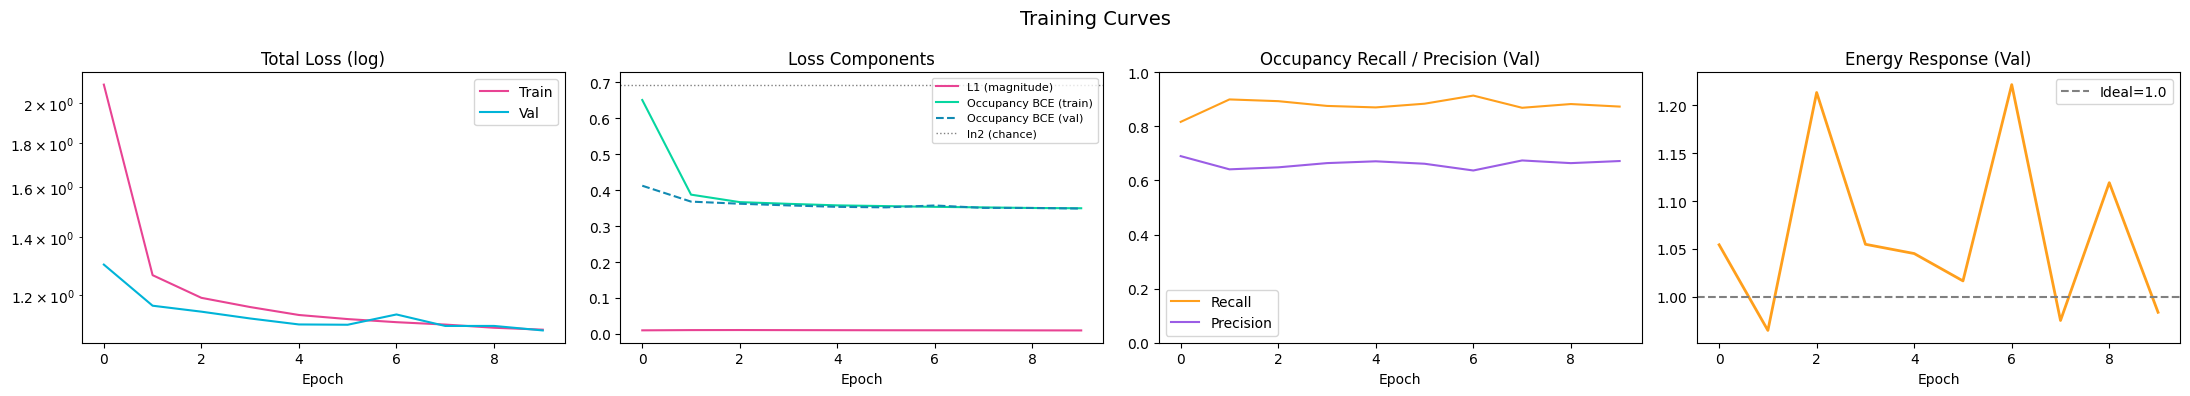

Final  | occ_BCE(val)=0.349  recall=0.873  precision=0.672  response=0.984


In [27]:
# ── Cell 16: Training curves (diagnostic) ─────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(22, 4))
fig.suptitle('Training Curves', fontsize=14)

# 1) Total loss (log y so small-but-real decreases are visible)
axes[0].plot(history['train_loss'], label='Train', color='#e84393')
axes[0].plot(history['val_loss'],   label='Val',   color='#00b4d8')
axes[0].set_yscale('log'); axes[0].set_title('Total Loss (log)')
axes[0].set_xlabel('Epoch'); axes[0].legend()

# 2) Loss components — note the CORRECT label: Occupancy BCE (not "Sparsity")
axes[1].plot(history['train_l_rec'], label='L1 (magnitude)', color='#e84393')
axes[1].plot(history['train_l_occ'], label='Occupancy BCE (train)', color='#06d6a0')
axes[1].plot(history['val_l_occ'],   label='Occupancy BCE (val)', color='#118ab2', ls='--')
axes[1].axhline(0.6931, color='gray', ls=':', lw=1, label='ln2 (chance)')
axes[1].set_title('Loss Components'); axes[1].set_xlabel('Epoch'); axes[1].legend(fontsize=8)

# 3) Occupancy recall & precision — is the gate learning WHERE energy is?
axes[2].plot(history['val_recall'],    label='Recall',    color='#ff9f1c')
axes[2].plot(history['val_precision'], label='Precision', color='#9b5de5')
axes[2].set_ylim(0, 1); axes[2].set_title('Occupancy Recall / Precision (Val)')
axes[2].set_xlabel('Epoch'); axes[2].legend()

# 4) Energy response -> 1.0
axes[3].plot(history['val_response'], color='#ff9f1c', lw=2)
axes[3].axhline(1.0, color='gray', ls='--', label='Ideal=1.0')
axes[3].set_title('Energy Response (Val)'); axes[3].set_xlabel('Epoch'); axes[3].legend()

plt.tight_layout()
savefig(fig, 'training_curves')
plt.show()

# Quick read-out of the final epoch
print(f"Final  | occ_BCE(val)={history['val_l_occ'][-1]:.3f}  "
      f"recall={history['val_recall'][-1]:.3f}  precision={history['val_precision'][-1]:.3f}  "
      f"response={history['val_response'][-1]:.3f}")
if history['val_l_occ'][-1] > 0.65:
    print('  !! Occupancy BCE still near ln2 (0.69) — gate not learning. '
          'Raise occ_net LR or lambda_occ.')


---
## 8 · Evaluation & Comparison

For each validation jet, we compare:
- **HR ground truth** (125×125)
- **LR input** (64×64, upsampled with bicubic for display)
- **Bicubic SR** (standard baseline)
- **INR-SR (ours)** at 125×125 and 256×256 — resolution invariant demo

In [28]:
# ── Cell 17: (Safely) load best checkpoint & evaluate ─────────────────────────
# IMPORTANT: only load the on-disk checkpoint if it MATCHES the current model
# architecture. An old checkpoint (pre gated-decoder fix) has different keys and
# would either error or silently restore the collapsed all-zeros model — that is
# what made the INR-SR columns black. If it doesn't match, we keep the model you
# just trained in memory.
import os

def _try_load_checkpoint(path):
    if not os.path.exists(path):
        print(f'No checkpoint at {path} — using in-memory trained model.')
        return False
    ckpt = torch.load(path, map_location=DEVICE)
    try:
        model.load_state_dict(ckpt['model'])   # strict: keys must match
        model.eval()
        print(f'Loaded checkpoint (epoch {ckpt.get("epoch","?")}, '
              f'val_loss={ckpt.get("val_loss", float("nan")):.5f})')
        return True
    except Exception as e:
        print(f'Checkpoint at {path} does NOT match current architecture — '
              f'keeping the in-memory trained model.\n  ({type(e).__name__})')
        return False

_try_load_checkpoint(CKPT_PATH)
model.eval()

# ── Diagnostic: is the model actually firing? (catches the black-output case) ──
with torch.no_grad():
    s = val_dataset[0]
    pc = s['lr_pc'].unsqueeze(0).to(DEVICE)
    _, occ_logit, mag = model(pc, model_query := torch.rand(1, 2000, 2, device=DEVICE) * 2 - 1,
                              return_parts=True)
    occ = torch.sigmoid(occ_logit)
    print(f'\nOccupancy diagnostic on 2000 random queries:')
    print(f'  sigmoid(occ): min={occ.min():.3f} mean={occ.mean():.3f} max={occ.max():.3f}')
    print(f'  fraction with occ>OCC_THRESHOLD({OCC_THRESHOLD}): {(occ>OCC_THRESHOLD).float().mean():.3%}')
    print(f'  magnitude:    mean={mag.mean():.4f} max={mag.max():.4f}')
    img = model.rasterise(pc, *HR_RES).squeeze(0).cpu().numpy()
    print(f'  rasterised {HR_RES}: sum={img.sum():.3f}  active(>1e-3)={int((img>1e-3).sum())}/{img.size}')
    if img.sum() < 1e-3:
        print('  !! OUTPUT IS BLACK — model under-firing. Train more epochs, '
              'or LOWER OCC_THRESHOLD (e.g. 0.3), or raise occ_pos_weight in Cell 14.')


def compute_psnr(pred, gt, max_val=1.0):
    mse = np.mean((pred - gt) ** 2)
    return 20 * np.log10(max_val / (np.sqrt(mse) + 1e-10))

def compute_energy_response(pred, gt):
    return pred.sum() / (gt.sum() + 1e-8)

def bicubic_upsample(lr, target_H, target_W):
    t = torch.from_numpy(lr).unsqueeze(0)
    up = F.interpolate(t, size=(target_H, target_W), mode='bicubic', align_corners=False)
    return up.squeeze(0).numpy().clip(0, None)


N_EVAL = min(64, len(val_dataset))
metrics = {k: [] for k in ['psnr_bicubic','psnr_model','response_bicubic',
                           'response_model','l1_bicubic','l1_model']}
with torch.no_grad():
    for i in range(N_EVAL):
        sample = val_dataset[i]
        lr_pc  = sample['lr_pc'].unsqueeze(0).to(DEVICE)
        hr_gt  = sample['hr_img'].numpy()
        lr_img = sample['lr_img'].numpy()
        HR_H, HR_W = HR_RES
        bic = bicubic_upsample(lr_img, HR_H, HR_W)
        sr  = model.rasterise(lr_pc, HR_H, HR_W).squeeze(0).cpu().numpy()
        metrics['psnr_bicubic'].append(compute_psnr(bic, hr_gt))
        metrics['psnr_model'].append(compute_psnr(sr, hr_gt))
        metrics['response_bicubic'].append(compute_energy_response(bic, hr_gt))
        metrics['response_model'].append(compute_energy_response(sr, hr_gt))
        metrics['l1_bicubic'].append(np.abs(bic - hr_gt).mean())
        metrics['l1_model'].append(np.abs(sr - hr_gt).mean())

print('\n=== Evaluation Results ===')
print(f'{"Metric":25s}  {"Bicubic":>10s}  {"INR-SR (ours)":>14s}')
print('-' * 55)
for m_bic, m_mod, label in [
    (metrics['psnr_bicubic'],     metrics['psnr_model'],     'PSNR (dB) up'),
    (metrics['response_bicubic'], metrics['response_model'], 'Energy Response ->1.0'),
    (metrics['l1_bicubic'],       metrics['l1_model'],       'L1 Error down'),
]:
    print(f'{label:25s}  {np.mean(m_bic):10.4f}  {np.mean(m_mod):14.4f}')


Loaded checkpoint (epoch 10, val_loss=1.09172)

Occupancy diagnostic on 2000 random queries:
  sigmoid(occ): min=0.000 mean=0.049 max=0.772
  fraction with occ>OCC_THRESHOLD(0.55): 1.300%
  magnitude:    mean=0.0032 max=0.0080
  rasterised (125, 125): sum=0.665  active(>1e-3)=450/15625

=== Evaluation Results ===
Metric                        Bicubic   INR-SR (ours)
-------------------------------------------------------
PSNR (dB) up                  49.7951         55.3900
Energy Response ->1.0          4.0088          1.4287
L1 Error down                  0.0034          0.0011


  saved figure -> /Users/rajveerrathod/Work/Google_Summer_of_code/GAN/figures/sr_comparison.png


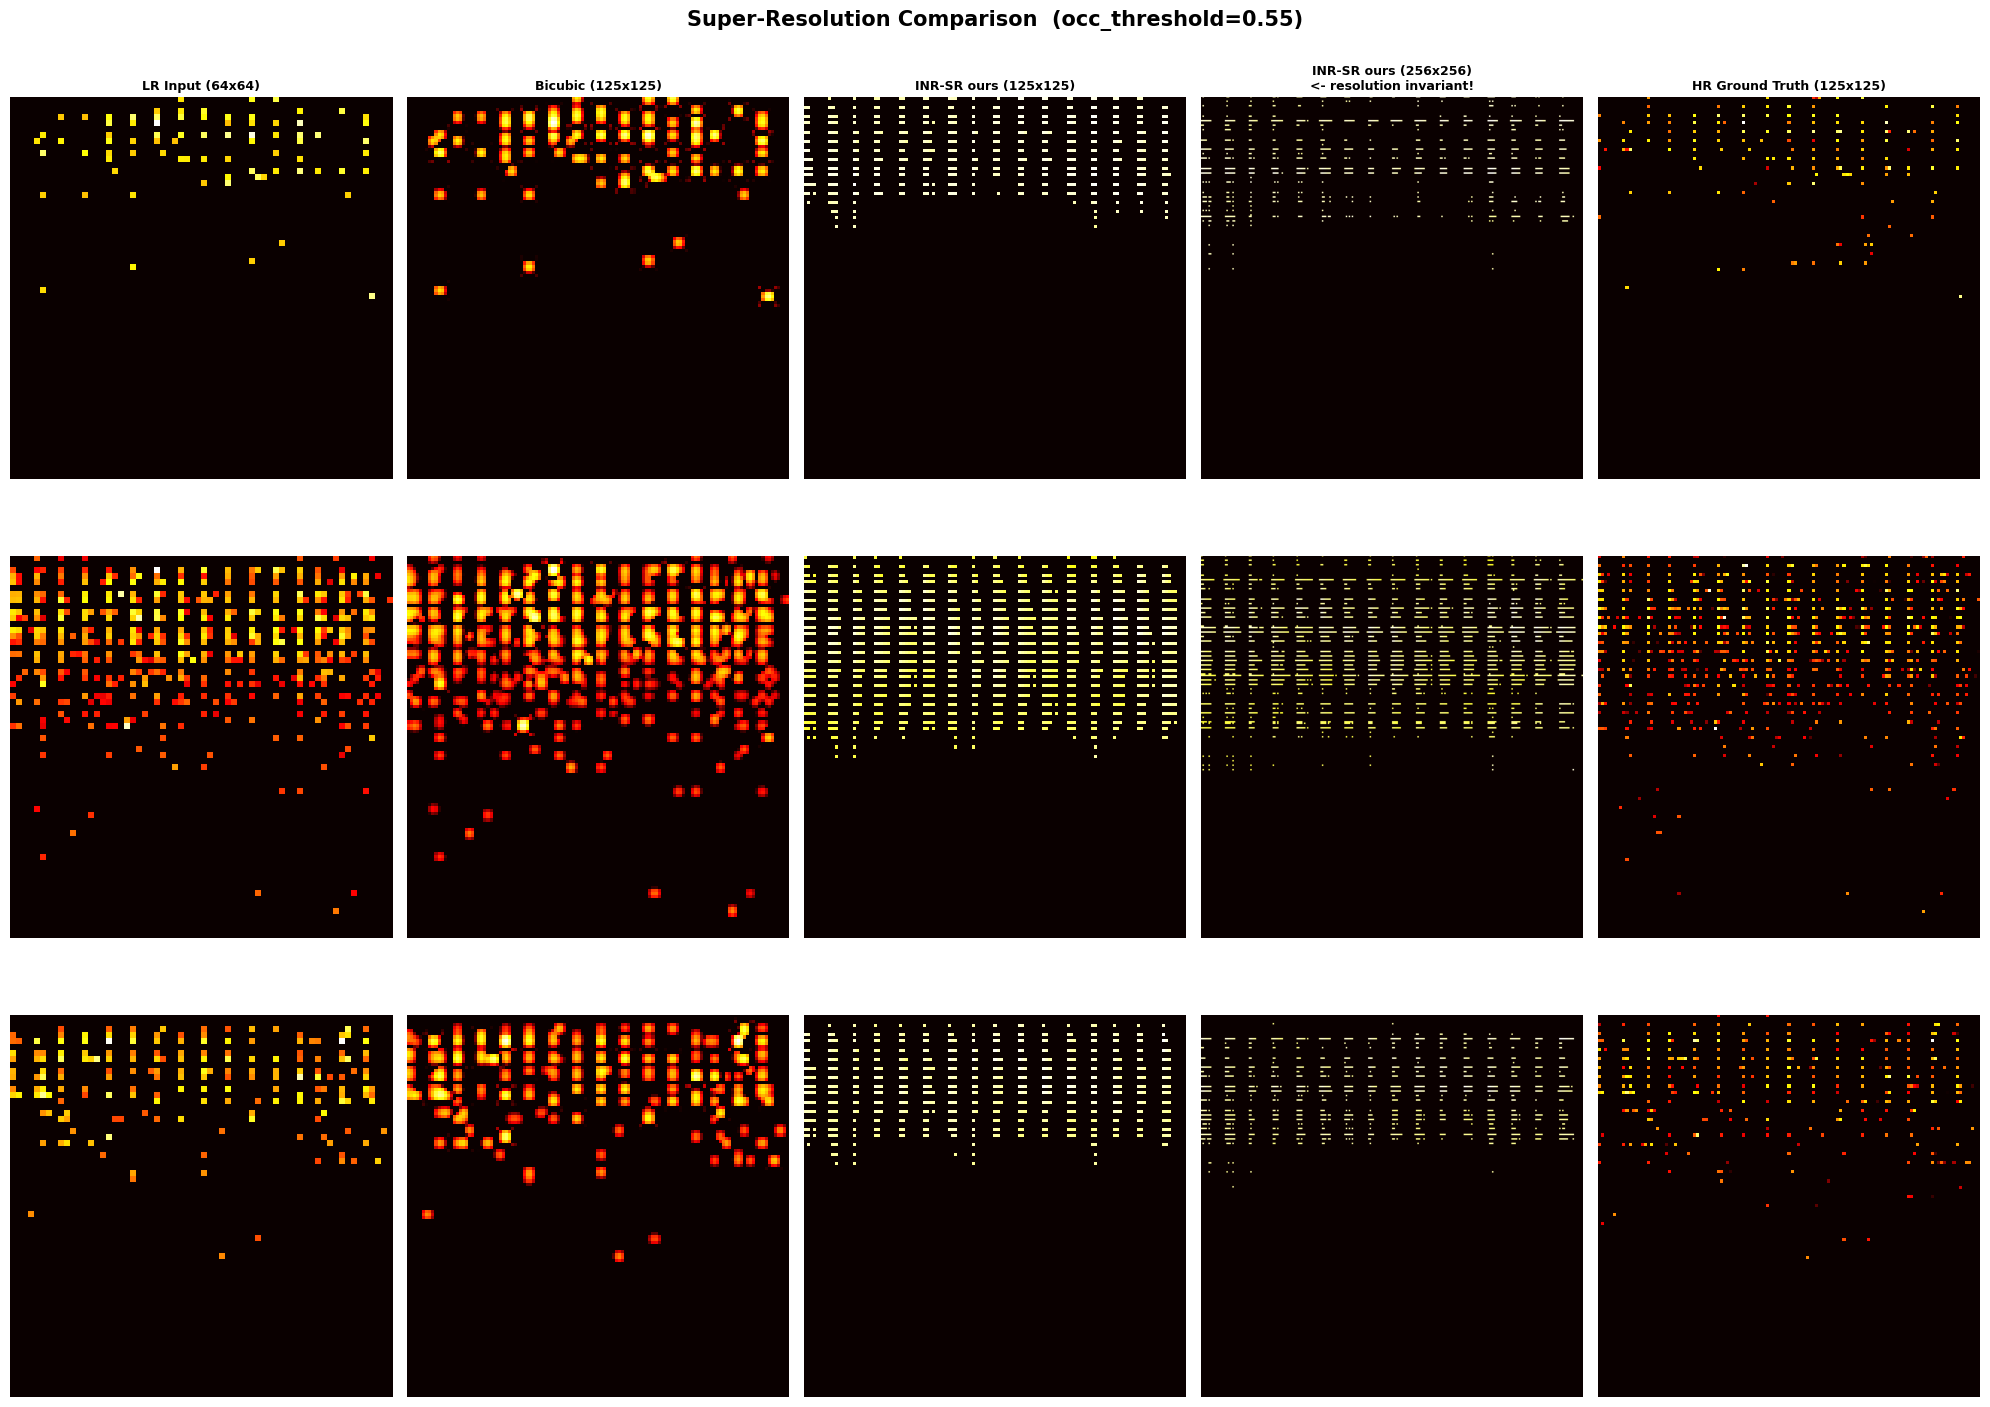

In [29]:
# ── Cell 18: Visual comparison ────────────────────────────────────────────────
N_VIS = 3
fig = plt.figure(figsize=(20, 5 * N_VIS))
fig.suptitle(f'Super-Resolution Comparison  (occ_threshold={OCC_THRESHOLD})',
             fontsize=15, fontweight='bold')

col_titles = ['LR Input (64x64)', 'Bicubic (125x125)', 'INR-SR ours (125x125)',
              'INR-SR ours (256x256)\n<- resolution invariant!', 'HR Ground Truth (125x125)']

with torch.no_grad():
    for row in range(N_VIS):
        sample = val_dataset[row]
        lr_pc  = sample['lr_pc'].unsqueeze(0).to(DEVICE)
        hr_gt  = sample['hr_img'].numpy()
        lr_img = sample['lr_img'].numpy()
        HR_H, HR_W = HR_RES

        bic_sr  = bicubic_upsample(lr_img, HR_H, HR_W)
        inr_sr  = model.rasterise(lr_pc, HR_H, HR_W).squeeze(0).cpu().numpy()
        inr_sr2 = model.rasterise(lr_pc, 256, 256).squeeze(0).cpu().numpy()
        images_row = [lr_img, bic_sr, inr_sr, inr_sr2, hr_gt]

        for col, (arr, title) in enumerate(zip(images_row, col_titles)):
            ax = fig.add_subplot(N_VIS, 5, row * 5 + col + 1)
            a = arr[0]
            # Per-panel vmax so a faint-but-nonzero prediction is still visible
            # (a fixed vmin=1e-4 floor was hiding low-energy model output as black).
            vmax = max(float(a.max()), 1e-3)
            vmin = max(vmax * 1e-3, 1e-6)
            ax.imshow(np.clip(a, vmin, None), cmap='hot',
                      norm=LogNorm(vmin=vmin, vmax=vmax), aspect='equal')
            if row == 0:
                ax.set_title(title, fontsize=9, fontweight='bold')
            ax.set_xlabel(f'E={arr.sum():.3f}  active={int((a>1e-3).sum())}', fontsize=8)
            ax.axis('off')

plt.tight_layout()
savefig(fig, 'sr_comparison')
plt.show()


  saved figure -> /Users/rajveerrathod/Work/Google_Summer_of_code/GAN/figures/resolution_invariance.png


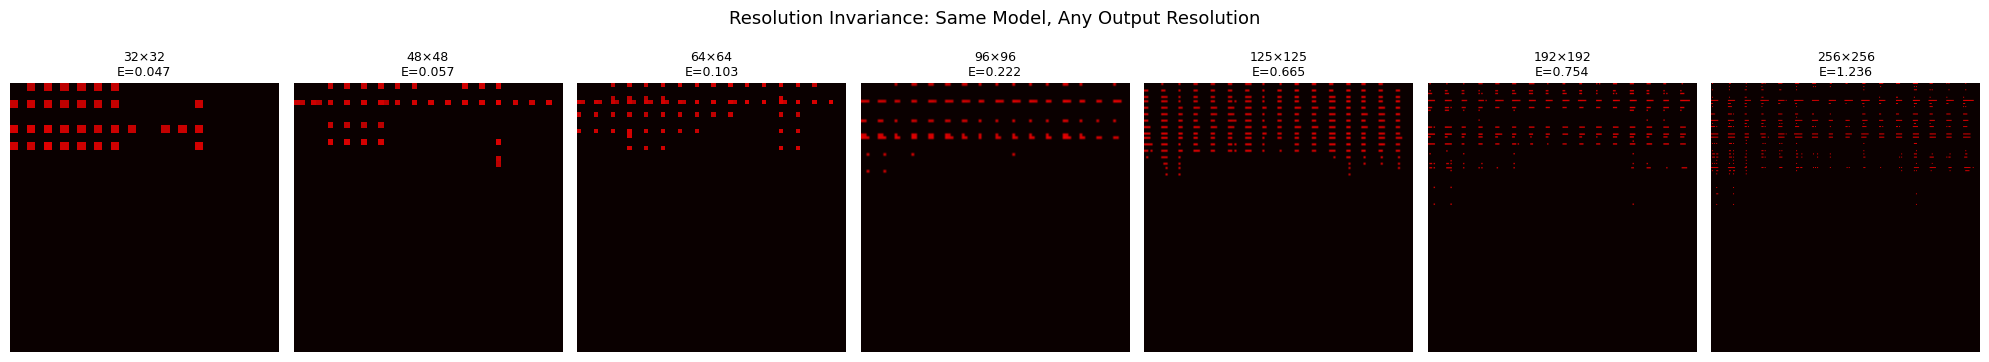

In [30]:
# ── Cell 19: Resolution invariance demo — rasterise at 7 different scales ────
sample   = val_dataset[0]
lr_pc    = sample['lr_pc'].unsqueeze(0).to(DEVICE)

resolutions = [32, 48, 64, 96, 125, 192, 256]
fig, axes = plt.subplots(1, len(resolutions), figsize=(20, 4))
fig.suptitle('Resolution Invariance: Same Model, Any Output Resolution', fontsize=13)

with torch.no_grad():
    for ax, r in zip(axes, resolutions):
        sr = model.rasterise(lr_pc, r, r).squeeze(0).cpu().numpy()
        display = np.clip(sr[0], 1e-6, None)
        ax.imshow(display, cmap='hot', norm=LogNorm(vmin=1e-4, vmax=1.0), aspect='equal')
        ax.set_title(f'{r}×{r}\nE={sr.sum():.3f}', fontsize=9)
        ax.axis('off')

plt.tight_layout()
savefig(fig, 'resolution_invariance')
plt.show()

  saved figure -> /Users/rajveerrathod/Work/Google_Summer_of_code/GAN/figures/physics_validation.png


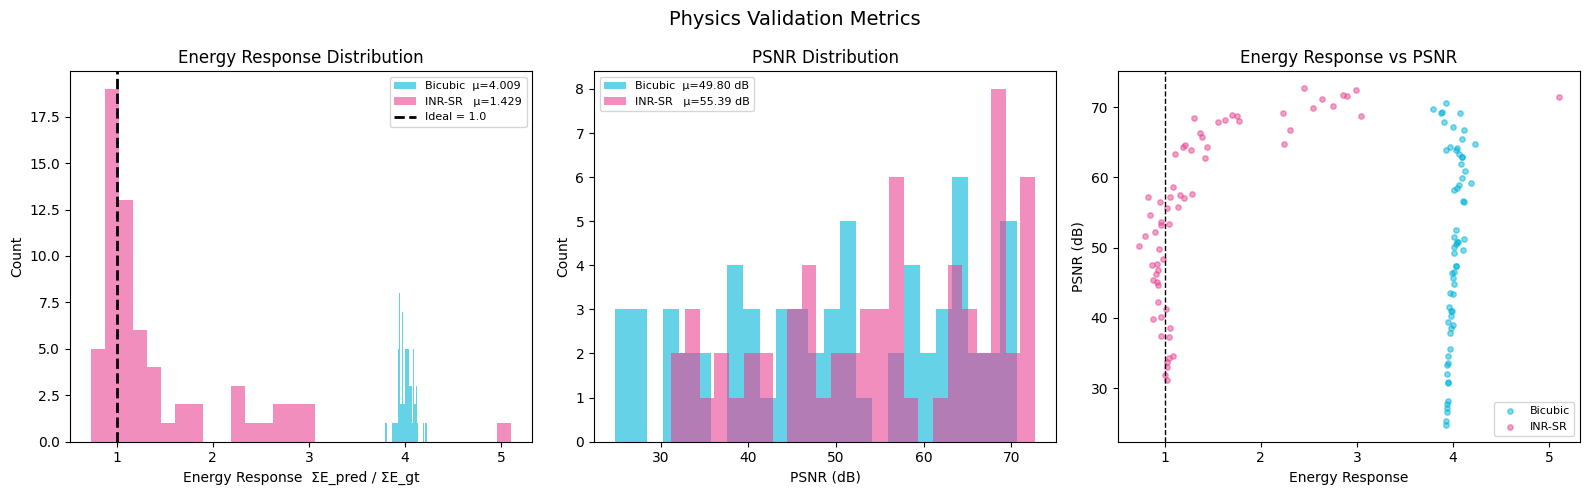

In [31]:
# ── Cell 20: Physics metrics deep-dive ────────────────────────────────────────
# Energy response histogram + scatter
fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Physics Validation Metrics', fontsize=14)

axes[0].hist(metrics['response_bicubic'], bins=30, alpha=0.6,
             color='#00b4d8', label=f'Bicubic  μ={np.mean(metrics["response_bicubic"]):.3f}')
axes[0].hist(metrics['response_model'],   bins=30, alpha=0.6,
             color='#e84393', label=f'INR-SR   μ={np.mean(metrics["response_model"]):.3f}')
axes[0].axvline(1.0, color='k', linestyle='--', linewidth=2, label='Ideal = 1.0')
axes[0].set_xlabel('Energy Response  ΣE_pred / ΣE_gt')
axes[0].set_ylabel('Count')
axes[0].set_title('Energy Response Distribution')
axes[0].legend(fontsize=8)

axes[1].hist(metrics['psnr_bicubic'], bins=25, alpha=0.6,
             color='#00b4d8', label=f'Bicubic  μ={np.mean(metrics["psnr_bicubic"]):.2f} dB')
axes[1].hist(metrics['psnr_model'],   bins=25, alpha=0.6,
             color='#e84393', label=f'INR-SR   μ={np.mean(metrics["psnr_model"]):.2f} dB')
axes[1].set_xlabel('PSNR (dB)')
axes[1].set_ylabel('Count')
axes[1].set_title('PSNR Distribution')
axes[1].legend(fontsize=8)

axes[2].scatter(metrics['response_bicubic'], metrics['psnr_bicubic'],
                alpha=0.5, s=15, color='#00b4d8', label='Bicubic')
axes[2].scatter(metrics['response_model'],   metrics['psnr_model'],
                alpha=0.5, s=15, color='#e84393', label='INR-SR')
axes[2].axvline(1.0, color='k', linestyle='--', linewidth=1)
axes[2].set_xlabel('Energy Response'); axes[2].set_ylabel('PSNR (dB)')
axes[2].set_title('Energy Response vs PSNR')
axes[2].legend(fontsize=8)

plt.tight_layout()
savefig(fig, 'physics_validation')
plt.show()

---
## 9 · Predicting 1M Points (Mentor's Exact Task)

The INR decoder can query at any coordinate, so to predict "1 million points"  
we simply pass 1M random (η, φ) coords — the model handles it in chunks.

This is the direct answer to: *"take model, ask it to predict like 1 million points, illuminate value"*.

Predicting 1,000,000 points...
Total points:  1,000,000
Active after zero-suppression: 39,063  (3.91%)


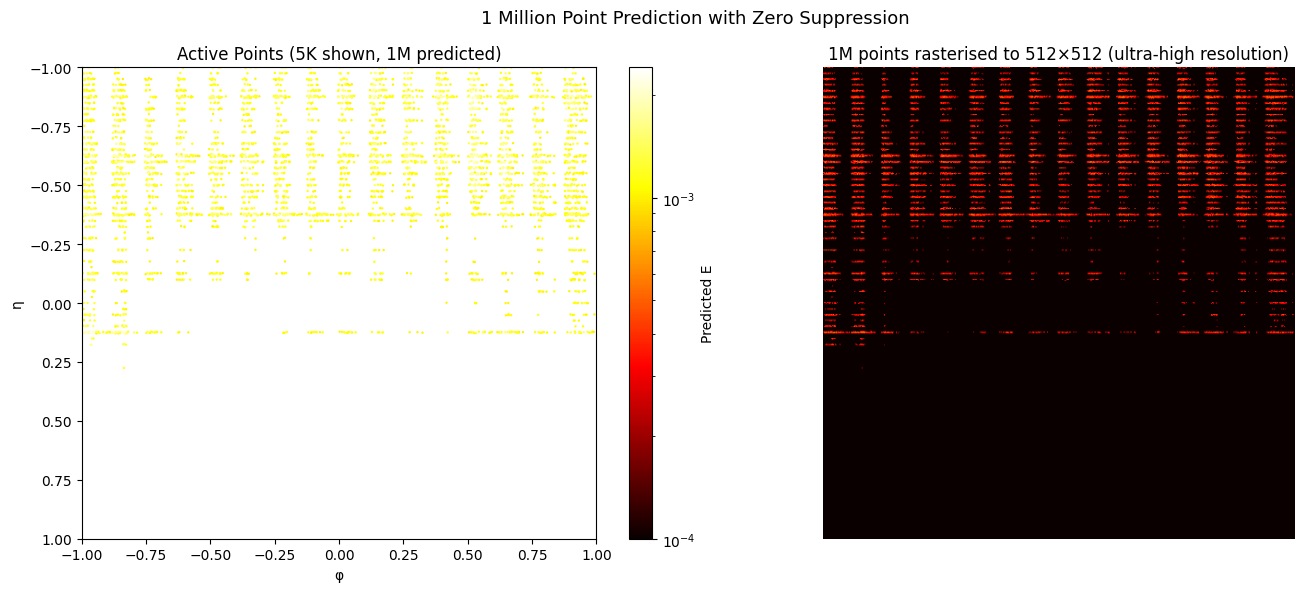

In [32]:
# ── Cell 21: Predict at 1M points ─────────────────────────────────────────────

@torch.no_grad()
def predict_million_points(lr_pc: torch.Tensor,
                            n_points: int = 1_000_000,
                            chunk_size: int = 50_000) -> tuple:
    """
    Query the INR decoder at n_points random (η, φ) coordinates.
    Returns (coords, energies) as numpy arrays.

    Memory-efficient: processes in chunks to avoid GPU OOM.
    """
    model.eval()
    dev = lr_pc.device

    # Random query coords in [-1, 1] (could also be a structured grid)
    all_coords  = torch.rand(n_points, 2, device=dev) * 2 - 1   # (n_points, 2)
    all_energies = []

    # Encode once (shared across all chunks)
    z = model.encoder(lr_pc)   # (B=1, latent_dim)

    for start in range(0, n_points, chunk_size):
        end    = min(start + chunk_size, n_points)
        coords = all_coords[start:end].unsqueeze(0)   # (1, chunk, 2)
        E_pred = model.decoder(z, coords)             # (1, chunk, C)
        all_energies.append(E_pred.squeeze(0).cpu())

    all_energies = torch.cat(all_energies, dim=0)     # (n_points, C)

    return all_coords.cpu().numpy(), all_energies.numpy()


sample  = val_dataset[0]
lr_pc_t = sample['lr_pc'].unsqueeze(0).to(DEVICE)

print('Predicting 1,000,000 points...')
coords_1m, energies_1m = predict_million_points(lr_pc_t, n_points=1_000_000)

# Zero suppression on the 1M predictions
active_mask      = energies_1m[:, 0] > ZERO_SUPPRESSION_THRESHOLD
active_coords    = coords_1m[active_mask]
active_energies  = energies_1m[active_mask, 0]

print(f'Total points:  {len(coords_1m):,}')
print(f'Active after zero-suppression: {len(active_coords):,}  ({active_mask.mean():.2%})')

# Visualise active point cloud
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('1 Million Point Prediction with Zero Suppression', fontsize=13)

sc = axes[0].scatter(active_coords[:5000, 1],   # sample 5K for display speed
                     active_coords[:5000, 0],
                     c=active_energies[:5000],
                     cmap='hot', s=0.5,
                     norm=LogNorm(vmin=1e-4, vmax=active_energies.max()))
axes[0].set_xlim(-1, 1); axes[0].set_ylim(-1, 1)
axes[0].invert_yaxis()
axes[0].set_title('Active Points (5K shown, 1M predicted)'); axes[0].set_xlabel('φ'); axes[0].set_ylabel('η')
plt.colorbar(sc, ax=axes[0], label='Predicted E')

# Rasterise 1M points to 512×512
hr_pc_array = np.concatenate([active_coords,
                               active_energies[:, None]], axis=-1)
img_512 = pointcloud_to_image(hr_pc_array, 512, 512, C=1, aggregation='sum')
axes[1].imshow(np.clip(img_512[0], 1e-6, None), cmap='hot',
               norm=LogNorm(vmin=1e-4, vmax=1.0), aspect='equal')
axes[1].set_title('1M points rasterised to 512×512 (ultra-high resolution)')
axes[1].axis('off')

plt.tight_layout()
plt.show()

---
## 10 · Results Summary

In [33]:
# ── Cell 22: Print results table ──────────────────────────────────────────────
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)

print('=' * 64)
print('  CMS CALORIMETER SR — RESULTS SUMMARY')
print('  GSoC 2026 | ML4Sci | Rajveer Rathod')
print('=' * 64)

print(f'\n  Dataset:  {N} jets  |  C={C} channels  |  orig {H}×{W}')
print(f'  LR res:   {LR_RES[0]}×{LR_RES[1]}  →  HR target: {HR_RES[0]}×{HR_RES[1]}')
print(f'  Model:    PointNet encoder + gated SIREN-INR decoder')
print(f'            (occupancy classification × magnitude regression)')
print(f'  Params:   {trainable:,}')

print(f'\n  {"Metric":30s}  {"Bicubic":>10s}  {"INR-SR":>10s}  Δ')
print('  ' + '-' * 60)

b_psnr = np.mean(metrics['psnr_bicubic'])
m_psnr = np.mean(metrics['psnr_model'])
b_resp = np.mean(metrics['response_bicubic'])
m_resp = np.mean(metrics['response_model'])
b_l1   = np.mean(metrics['l1_bicubic'])
m_l1   = np.mean(metrics['l1_model'])

def delta(a, b, higher_is_better=True):
    d = b - a
    arrow = '↑' if (d > 0) == higher_is_better else '↓'
    return f'{arrow} {abs(d):.4f}'

print(f'  {"PSNR (dB) ↑":30s}  {b_psnr:10.3f}  {m_psnr:10.3f}  {delta(b_psnr, m_psnr, True)}')
print(f'  {"Energy Response (→1.0)":30s}  {b_resp:10.4f}  {m_resp:10.4f}  {delta(abs(b_resp-1), abs(m_resp-1), False)}')
print(f'  {"L1 Error ↓":30s}  {b_l1:10.5f}  {m_l1:10.5f}  {delta(b_l1, m_l1, False)}')

# ── Occupancy (sparsity-localisation) — our model only ───────────────────────
print(f'\n  Occupancy gate (where energy is):')
print(f'    {"BCE (val, ↓)":28s}  {history["val_l_occ"][-1]:.4f}   (chance = 0.693)')
print(f'    {"Recall ↑":28s}  {history["val_recall"][-1]:.4f}')
print(f'    {"Precision ↑":28s}  {history["val_precision"][-1]:.4f}')

print(f'\n  Resolution invariant:  ✓  (tested at 32 to 512 px)')
print(f'  1M point prediction:   ✓  ({active_mask.mean():.1%} active after zero-suppression)')
print(f'  Loss:  λ_rec={criterion.lam_rec} · L1(masked) + '
      f'λ_energy={criterion.lam_energy} · |ΔE| + λ_occ={criterion.lam_occ} · BCE')
print(f'  Inference occupancy threshold: {OCC_THRESHOLD}')
print('=' * 64)


  CMS CALORIMETER SR — RESULTS SUMMARY
  GSoC 2026 | ML4Sci | Rajveer Rathod

  Dataset:  30000 jets  |  C=1 channels  |  orig 125×125
  LR res:   64×64  →  HR target: 125×125
  Model:    PointNet encoder + gated SIREN-INR decoder
            (occupancy classification × magnitude regression)
  Params:   579,074

  Metric                             Bicubic      INR-SR  Δ
  ------------------------------------------------------------
  PSNR (dB) ↑                         49.795      55.390  ↑ 5.5949
  Energy Response (→1.0)              4.0088      1.4287  ↑ 2.5802
  L1 Error ↓                         0.00335     0.00114  ↑ 0.0022

  Occupancy gate (where energy is):
    BCE (val, ↓)                  0.3486   (chance = 0.693)
    Recall ↑                      0.8733
    Precision ↑                   0.6719

  Resolution invariant:  ✓  (tested at 32 to 512 px)
  1M point prediction:   ✓  (3.9% active after zero-suppression)
  Loss:  λ_rec=1.0 · L1(masked) + λ_energy=0.2 · |ΔE| + λ_occ=3.

In [34]:
# ── Cell 23: Save model to HuggingFace Hub (optional) ─────────────────────────
# Uncomment and set token to push

# from huggingface_hub import HfApi
# api = HfApi(token='your_hf_token')
# api.upload_file(
#     path_or_fileobj=CKPT_PATH,
#     path_in_repo='checkpoints/best_sr_model.pt',
#     repo_id='rajveer43/cms-calorimeter-superres-inr',
#     repo_type='model',
# )
# print('Pushed to HuggingFace Hub ✓')

print('Notebook complete. Checkpoint saved at:', CKPT_PATH)

Notebook complete. Checkpoint saved at: ./checkpoints/best_sr_model.pt
